# Evaluation of SVS Ensemble Simulations for Soil Moisture, Temperature, and Deep Percolation

This script evaluates the performance of an ensemble of the SVS model simulations against field observations of soil moisture, soil temperature, and deep percolation. 

## Methodology

1. **Data Loading:**
   - Loads field observations of soil moisture, soil temperature, and deep percolation from Parquet and CSV files.
   - Loads hourly meteorological forcing data from a CSV file.
   - Loads daily snow depth data from CSV files.
   - Filters and preprocesses the data to ensure consistency and select relevant variables.

2. **Ensemble Output Processing:**
   - Loads SVS model output from Feather files for each ensemble member.
   - Calculates average values for specific variables (e.g., soil moisture at different depths, soil temperature).
   - Resamples the data to daily intervals for subsequent analysis.

3. **Evaluation Metrics Calculation:**
   - Calculates the Continuous Ranked Probability Score (CRPS) to assess the overall probabilistic skill of the ensemble in predicting soil moisture, soil temperature, and deep percolation.
   - Calculates the coefficient of determination (R²) and mean bias error (MBE) to evaluate the accuracy of the ensemble mean in reproducing the observed mean values.
   - Performs these calculations for different time periods (e.g., 2019-2020, 2020-2021, warm months, cold months) to assess seasonal and temporal variations in model performance.

4. **Visualization:**
   - Generates time-series plots comparing observed and simulated values for soil moisture, soil temperature, and deep percolation. The plots display the ensemble mean, the 5th and 95th percentiles of the ensemble, and the observed values (with uncertainty ranges for soil moisture and temperature).
   - Creates scatter plots comparing observed and simulated values for soil moisture and temperature, separately for warm and cold months. The plots include regression lines and annotations indicating the slope, intercept, correlation coefficient, and MBE.

## File Paths

* **Input Data:**
    - Hourly meteorological forcing: `../Data/OriginalForcingData.csv`
    - Field soil moisture: `../Data/FieldSoilMoisture_4Enclosures_4Lysimeters_201806_202210.parquet`
    - Field soil temperature: `../Data/FieldSoilTemperature_4Enclosures_4Lysimeters_201806_202210.parquet`
    - Field deep percolation: `../Data/FieldHourlyDeepPercolation_3Enclosures_4Lysimeters_201806_202210.csv`
    - Daily snow depth: `../Data/SaintGermainDeGrantham_DailySnowDepth_2013_2022.csv`
    - Field snow: `../Data/processed_manual_snow.csv`
    - Field soil suction: `../Data/FieldSoilSuction_4Enclosures_4Lysimeters_201806_202210.parquet`
    - SVS ensemble output files: `/Users/pinovanrijn/Desktop/no_sync/run_ens/ens_checkpoint/*.feather`

* **Output Data:**
    - Figures: Saved in the `../Figures` directory.
    - CRPS report: `./results/crps_report.txt` (not implemented in the provided code)

## Dependencies

- **Python libraries:** `pathlib`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `dask`, `crpsnb`
- **Helper functions:** Assumed to be defined in a separate `helpers` module.

## Key Assumptions

- The observed and simulated data are properly aligned in time and have consistent units.
- The uncertainty in observed soil moisture and temperature can be represented by uniform distributions.
- The CRPS calculation is implemented correctly in the `crpsnb` library.

## Author

Alireza Amani

## Date

2024-07-24


# Main

In [158]:
# Imports ----------------------------------------------------------------------
from pathlib import Path
from gc import collect
from importlib import reload
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import linregress

import dask
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd

import helpers
reload(helpers)

from crpsnb.crps import crps_neighboor
# ______________________________________________________________________________
# Variables --------------------------------------------------------------------

## paths to data and output
paths = {
    'hourly_forcing': Path(
        '../Data/OriginalForcingData.csv'
    ),
    'field_moist': Path(
        '../Data/FieldSoilMoisture_4Enclosures_4Lysimeters_201806_202210.parquet'
    ),
    'field_temp': Path(
        '../Data/FieldSoilTemperature_4Enclosures_4Lysimeters_201806_202210.parquet'
    ),
    'field_percolation': Path(
        '../Data/FieldHourlyDeepPercolation_3Enclosures_4Lysimeters_201806_202210.csv'
    ),
    'output_dir': Path(
         './Results/ens_run/'
    ),
    'daily_snow': Path(
        '../Data/SaintGermainDeGrantham_DailySnowDepth_2013_2022.csv'
    ),
    'field_snow': Path('../Data/processed_manual_snow.csv'),

    'field_susction': Path("../Data/FieldSoilSuction_4Enclosures_4Lysimeters_201806_202210.parquet"),

    'figures_dir': Path("../Figures"),
}

## relevant soil moisture sensors
RELEVANT_MOIST_SENSORS = (
    'L2_600mm_int_Moisture_percent', 'L2_600mm_ext_Moisture_percent',
    'L2_1850mm_int_Moisture_percent', 'L2_1750mm_int_Moisture_percent',
    'L2_1750mm_ext_Moisture_percent', 'L2_225mm_ext_Moisture_percent',
    'L2_75mm_ext_Moisture_percent', 'L1_1850mm_int_Moisture_percent',
    'L1_1750mm_int_Moisture_percent', 'L1_1750mm_ext_Moisture_percent',
    'L1_225mm_ext_Moisture_percent', 'L1_75mm_ext_Moisture_percent'
)

## relevant soil temperature sensors
RELEVANT_TEMP_SENSORS = (
    'L2_600mm_int_Temperature_degc', 'L2_600mm_ext_Temperature_degc',
    'L2_1850mm_int_Temperature_degc', 'L2_1750mm_int_Temperature_degc',
    'L2_1750mm_ext_Temperature_degc', 'L2_225mm_ext_Temperature_degc',
    'L2_75mm_ext_Temperature_degc', 'L1_1850mm_int_Temperature_degc',
    'L1_1750mm_int_Temperature_degc', 'L1_1750mm_ext_Temperature_degc',
    'L1_225mm_ext_Temperature_degc', 'L1_75mm_ext_Temperature_degc',
    'L3_75mm_ext_Temperature_degc', 'L4_75mm_ext_Temperature_degc',
)

## random seed for reproducibility
RSEED = 1915

## number of samples for observation noise
NSAMPLE = 30

## white noise parameters for observation uncertainty
MOIST_MU = 0.0 # m3/m3
MOIST_SIGMA = 0.01 # m3/m3

TEMP_MU = 0.0 # deg C
TEMP_SIGMA = 0.33 # deg C

SNOW_MU = 0.0 # cm
SNOW_SIGMA = 0.33 # cm

## path to save results
REPORT_TEXT_FILE = Path('./results/crps_report.txt')

###
REPORT_COLS = [
    'Variable', 'Depth', 'Temporal Scale', 'Season', 'Metric', 'Unit', 'Value',
    'nValues',
]

## warm/cold period months
WARM_MONTHS = [4, 5, 6, 7, 8, 9, 10]
COLD_MONTHS = [1, 2, 3, 11, 12]

## colors
# WARM_GREY = '#A9A9A9'
# SLATE_GREY = '#708090'
LIGHT_GREY = "#D3D3D3"
CHARCOAL = '#36454F'
TEAL = '#008080'
GOLD_BROWN = '#CC9966'
LIGHT_BLUE = '#6699CC'

WARM_GREY = '#707070'  # Make this darker if using Option 2
SLATE_GREY = '#8090A0'  # Make this cooler if using Option 2

DARK_PURPLE = '#663366'

## date ranges for evaluation, including warm and cold periods
PERIOD_1_D = pd.date_range(
    start='2019-09-01', end='2020-11-01', freq='1d', tz='UTC', inclusive='left',
)
# PERIOD_1_D_WARM = PERIOD_1_D[PERIOD_1_D.month.isin(WARM_MONTHS)]
# PERIOD_1_D_COLD = PERIOD_1_D[PERIOD_1_D.month.isin(COLD_MONTHS)]

PERIOD_2_D = pd.date_range(
    start='2020-11-01', end='2021-11-01', freq='1d', tz='UTC', inclusive='left',
)
# PERIOD_2_D_WARM = PERIOD_2_D[PERIOD_2_D.month.isin(WARM_MONTHS)]
# PERIOD_2_D_COLD = PERIOD_2_D[PERIOD_2_D.month.isin(COLD_MONTHS)]

PERIOD_3_D = pd.date_range(
    start='2021-11-01', end='2022-11-01', freq='1d', tz='UTC',  inclusive='left',
)
# PERIOD_3_D_WARM = PERIOD_3_D[PERIOD_3_D.month.isin(WARM_MONTHS)]
# PERIOD_3_D_COLD = PERIOD_3_D[PERIOD_3_D.month.isin(COLD_MONTHS)]

LOCAL_TZ = 'America/Montreal'

## aggregation functions
fivepct_fun = dd.Aggregation(
    name="5%",
    chunk=lambda s: s.quantile(0.05),
    agg=lambda s0: s0.sum(),
)

ninetyfivepct_fun = dd.Aggregation(
    name="95%",
    chunk=lambda s: s.quantile(0.95),
    agg=lambda s0: s0.sum(),
)


## assertions
for path in paths.values():
    assert path.exists(), f'Path not found: {path}'
# ______________________________________________________________________________
# Load data --------------------------------------------------------------------

## get path to individual output files
output_files = tuple(paths['output_dir'].glob('*.feather'))

## load data
### soil moisture
field_moist = pd.read_parquet(paths['field_moist'])
field_moist = field_moist.loc[field_moist["Unique_label_"].isin(RELEVANT_MOIST_SENSORS)]
field_moist = field_moist.set_index('Date Time (UTC)')

### soil temperature
field_temp = pd.read_parquet(paths['field_temp'])
field_temp = field_temp.loc[field_temp["Unique_label_"].isin(RELEVANT_TEMP_SENSORS)]
field_temp = field_temp.set_index('Date Time (UTC)')

### soil suction
field_suction = pd.read_parquet(paths['field_susction'])
field_suction = field_suction.set_index('Date Time (UTC)')

### forcing data
forcing = pd.read_csv(paths['hourly_forcing'])
forcing.index = pd.to_datetime(forcing['datetime_utc'], utc=True)

daily_snow = pd.read_csv(paths['daily_snow'])
daily_snow.set_index('Date', inplace=True)
daily_snow.index = pd.to_datetime(daily_snow.index)
daily_snow = daily_snow['2018-01-01':]

field_snow = pd.read_csv(paths['field_snow'], index_col=0)
field_snow.set_index('date', inplace=True)
field_snow.index = pd.to_datetime(field_snow.index)

### percolation
field_percolation = pd.read_csv(paths['field_percolation'])
field_percolation = field_percolation.loc[field_percolation["Lysimeter Number"].isin([1, 2, 4])]
field_percolation = field_percolation.set_index('Date Time (UTC)')
field_percolation.index = pd.to_datetime(field_percolation.index)
# ______________________________________________________________________________

# Evaluation Metrics and Visualization

## 1850 mm soil moisture

Loading SVS model output...
Done.
Calculating neighborhood-based CRPS...

CRPS (2019-09-01 to 2020-11-01): 0.0141
Calculating neighborhood-based CRPS...

CRPS (2020-11-01 to 2021-11-01): 0.0350

Calculating R2 and MBE for ensemble mean...

Full period: R2 = 0.0815, MBE = -0.0359
2019-09-01 to 2020-11-01: R2 = 0.1138, MBE = -0.0250
2020-11-01 to 2021-11-01: R2 = 0.3880, MBE = -0.0495
Warm months: R2 = -0.2299, MBE = -0.0449
Cold months: R2 = -0.4763, MBE = -0.0192


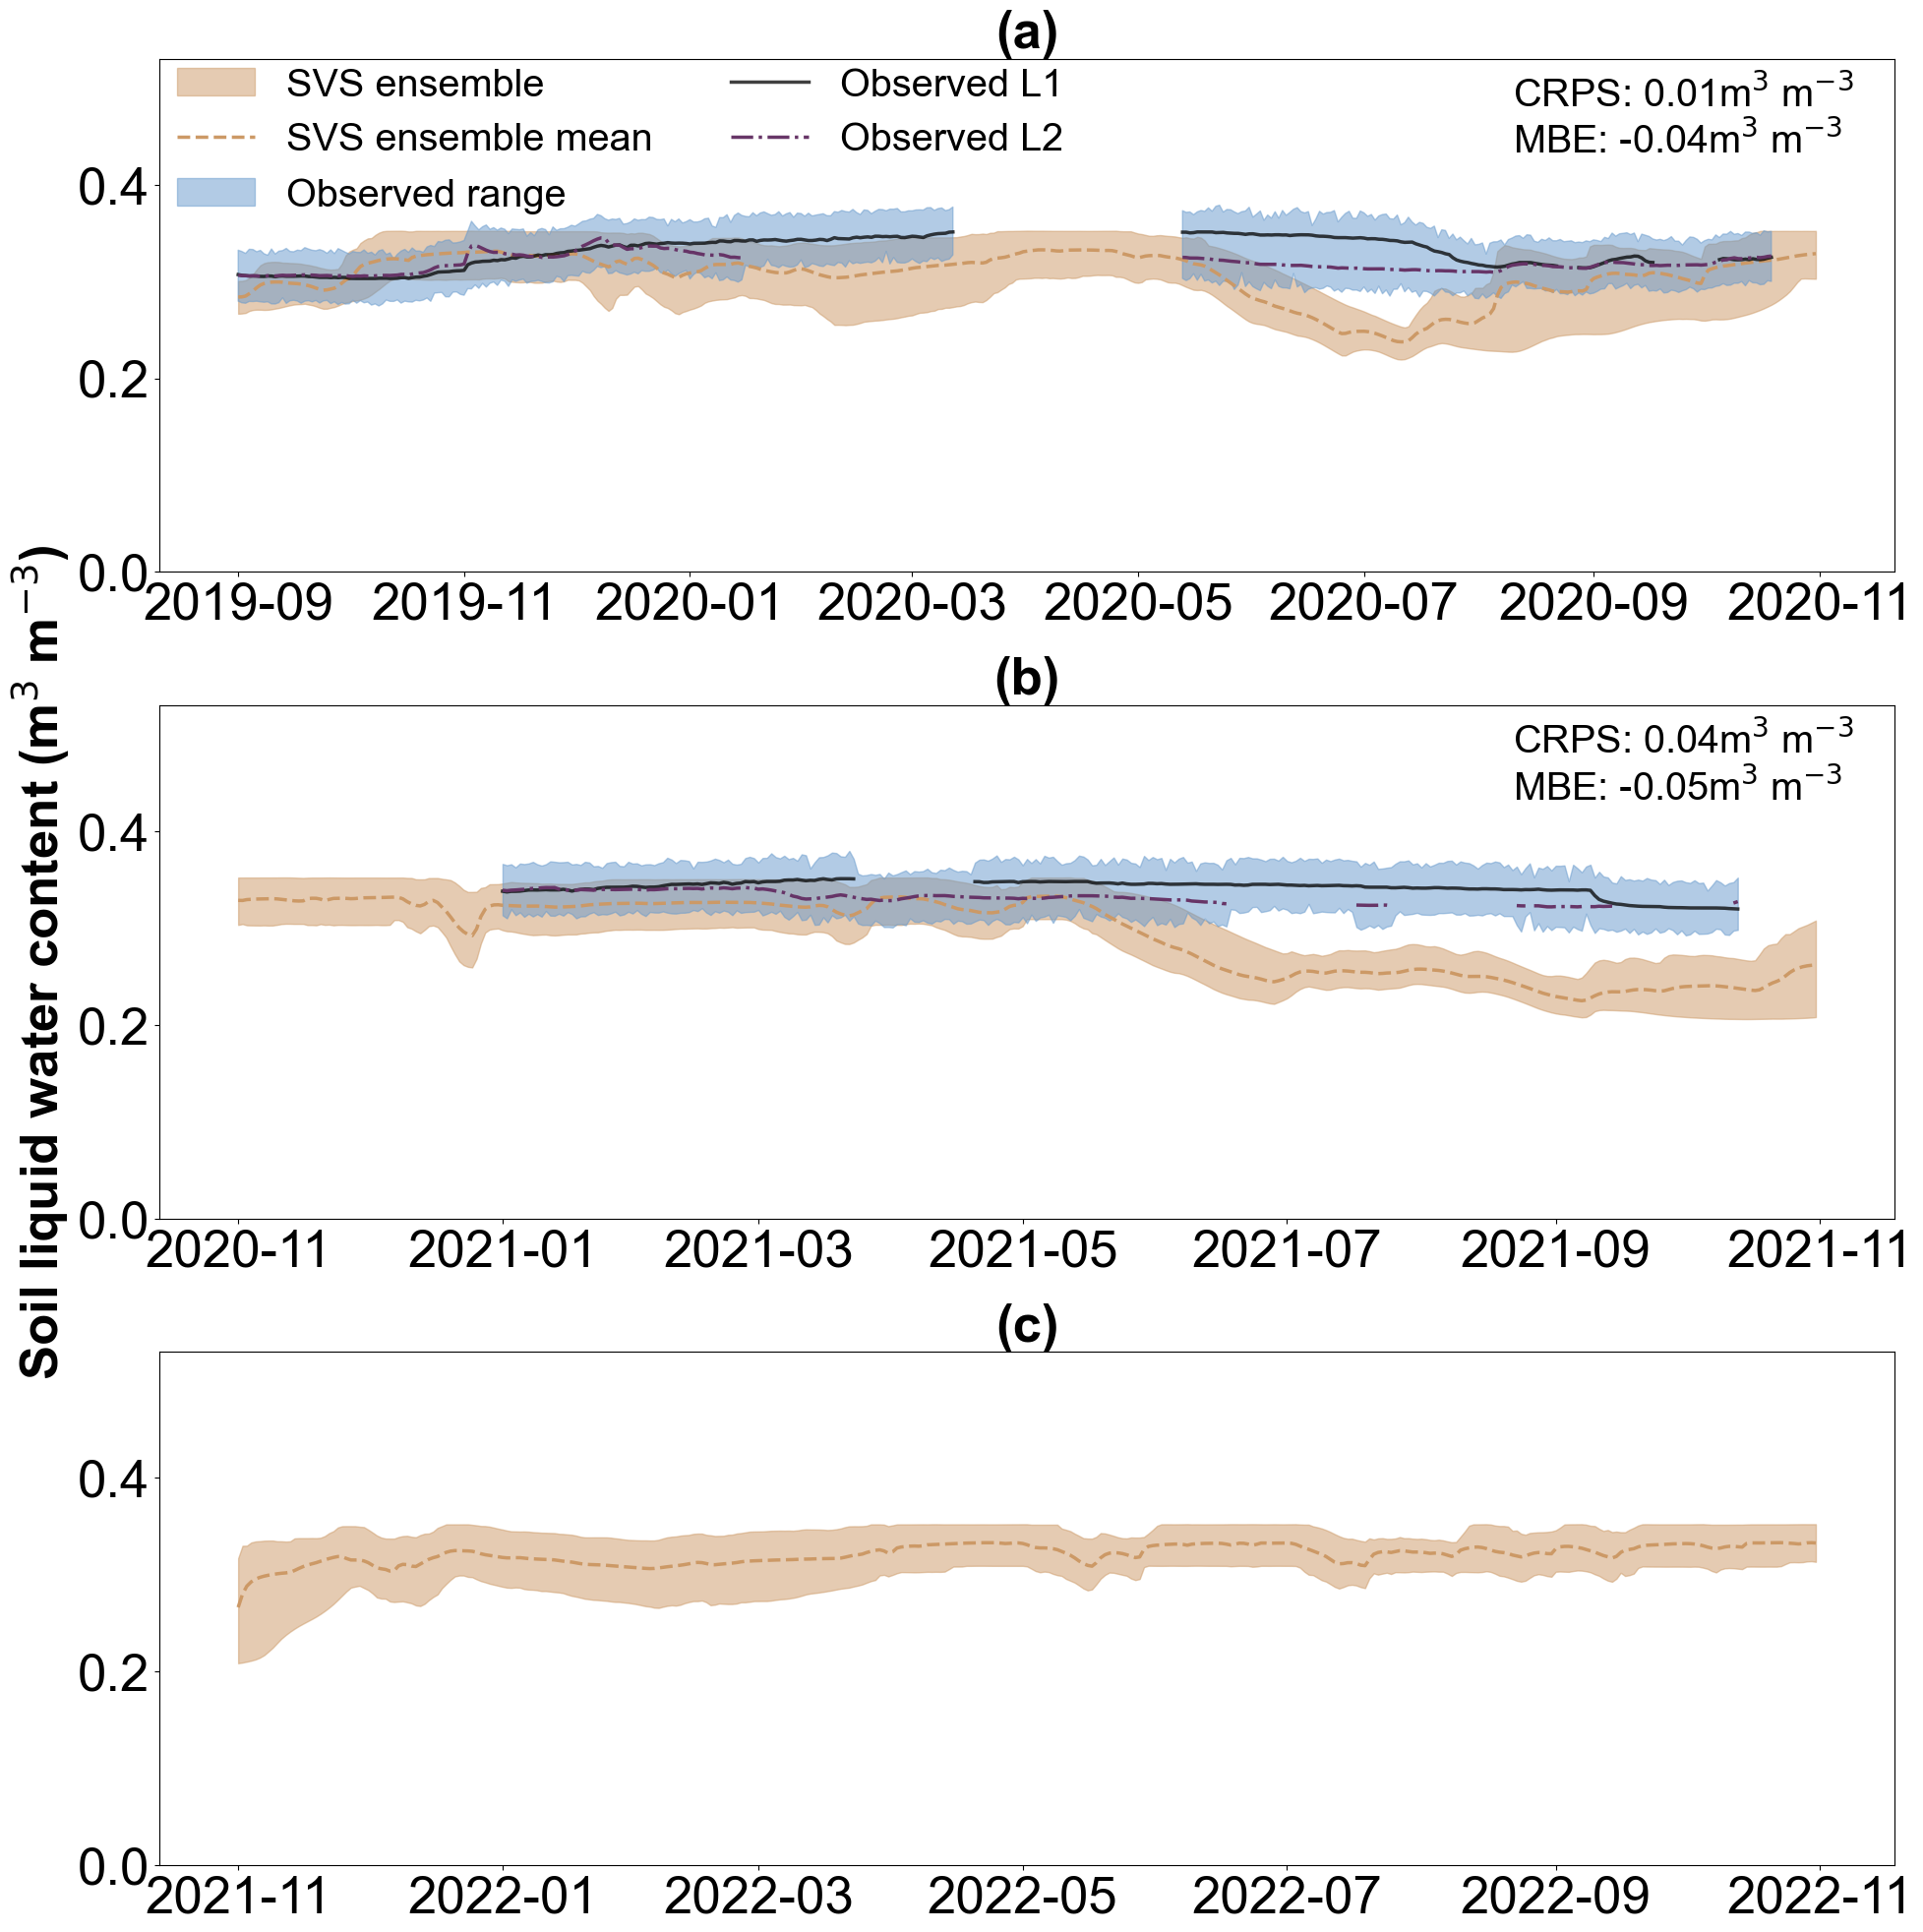

Warm months:
Slope: -0.6000, Intercept:  0.4779, R: -0.2299, p-value:  0.0000
Cold months:
Slope: -0.5189, Intercept:  0.4953, R: -0.4763  (r: -0.4763), p-value:  0.0000


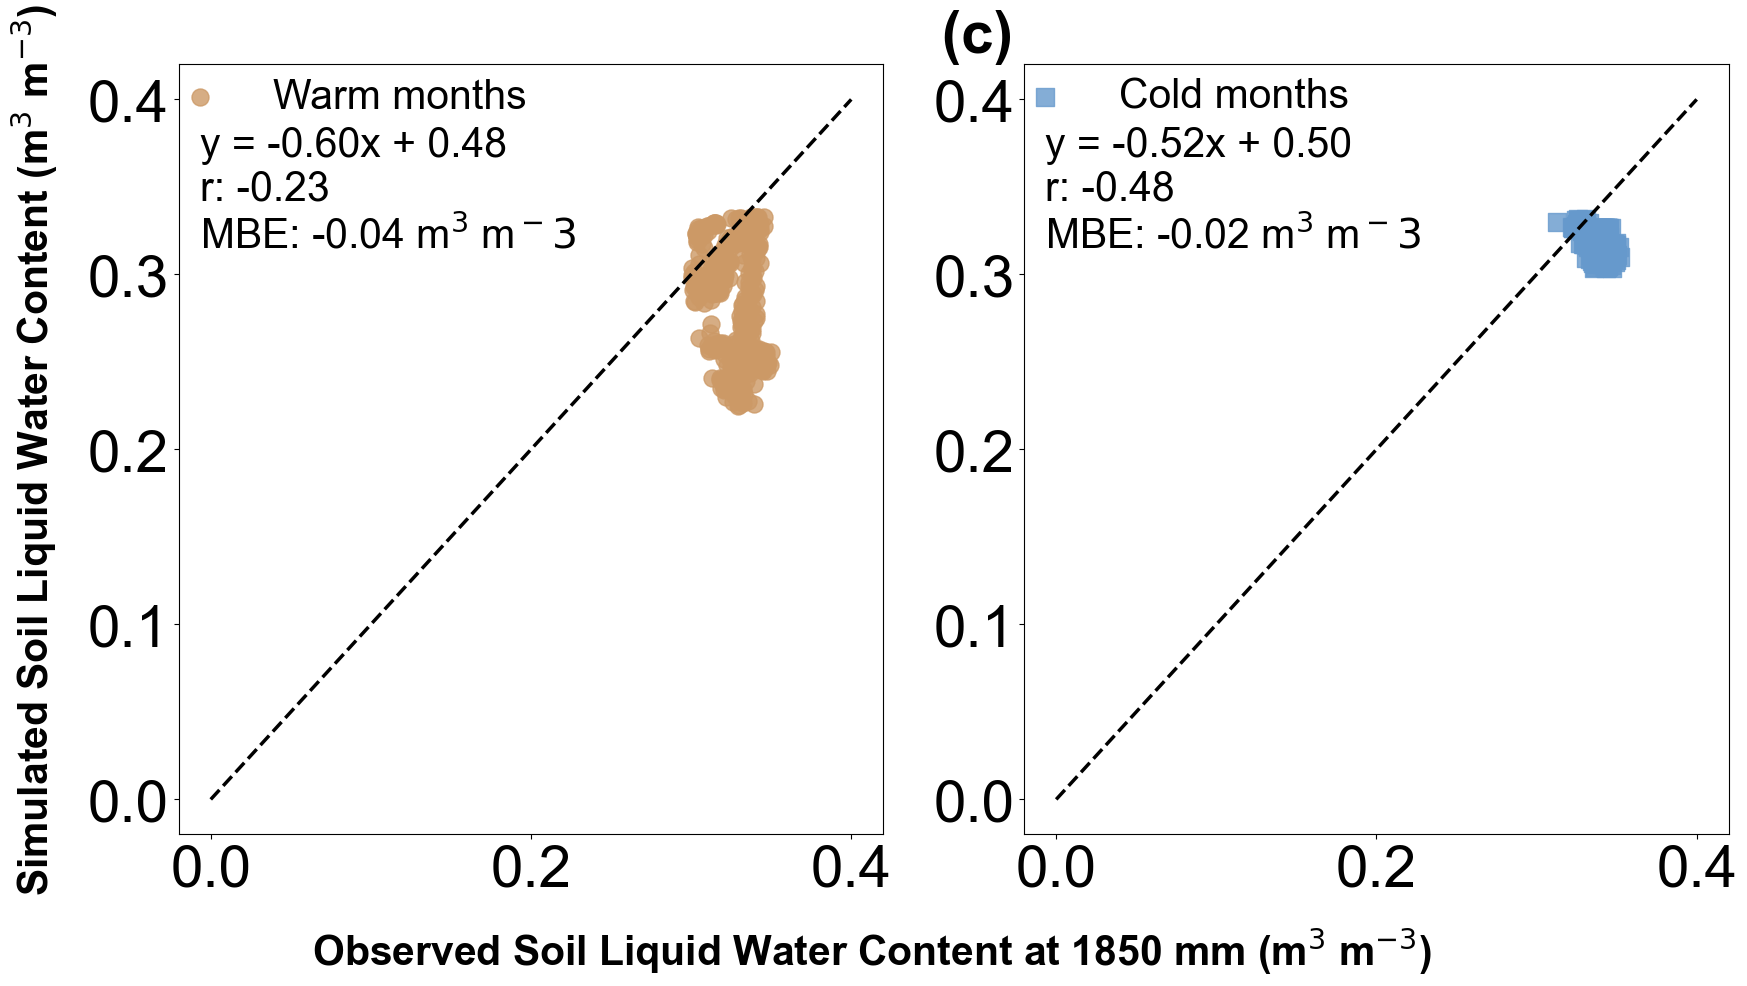

In [220]:
# observations (load and create ensemble)
drng = np.random.default_rng(RSEED)
obs_l1 = field_moist.loc[field_moist["Unique_label_"] == 'L1_1850mm_int_Moisture_percent', "Reading"].copy()
obs_l2 = field_moist.loc[field_moist["Unique_label_"] == 'L2_1850mm_int_Moisture_percent', "Reading"].copy()

## to daily
obs_l1 = obs_l1.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)
obs_l2 = obs_l2.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)

## ensemble creation
### indices where both sensors have data, only sensor 1 has data, and only sensor 2 has data
idx_both = obs_l1.dropna().index.intersection(obs_l2.dropna().index)
idx_l1 = obs_l1.dropna().index.difference(idx_both)
idx_l2 = obs_l2.dropna().index.difference(idx_both)
combined_idx = idx_both.union(idx_l1).union(idx_l2)

# create a dataframe with 2xNSAMPLE columns and
dfobs = pd.DataFrame(
    np.nan,
    index=combined_idx,
    columns=[f'obs_{i}' for i in range(2*NSAMPLE)]
)


# draw NSAMPLE samples from each sensor for the time steps where we have data from both sensors
sensor_1_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_both],
    add_value=0.03,
    n=NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_both],
    add_value=0.03,
    n=NSAMPLE, drng=drng, non_negative=True,
)

# draw 2xNSAMPLE samples from the sensor where we have data from only one sensor
sensor_1_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_l1],
    add_value=0.03,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_l2],
    add_value=0.03,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)

# fill the dataframe
dfobs.loc[idx_both, :] = np.hstack([sensor_1_sample_shared, sensor_2_sample_shared])
dfobs.loc[idx_l1, dfobs.columns[:2*NSAMPLE]] = sensor_1_sample_only
dfobs.loc[idx_l2, dfobs.columns[:2*NSAMPLE]] = sensor_2_sample_only

# load SVS model output
print('Loading SVS model output...')
ave_cols = dict(
    WSOIL_43_42 = ["WSOIL_43", "WSOIL_42"]
)
dfsvs = helpers.get_ensemble_output(
    output_files, ave_cols["WSOIL_43_42"], ave_cols=ave_cols
).pivot_table(
    index="date_utc", columns="member", values="WSOIL_43_42"
).resample('1d').mean()
print('Done.')

# find shared indices between the two datasets within PERIOD_1_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_1_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2019-09-01 to 2020-11-01): {crps_neigh:.4f}')

# find shared indices between the two datasets within PERIOD_2_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_2_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2020-11-01 to 2021-11-01): {crps_neigh:.4f}')

# (There is no obs for the period 2021-11-01 to 2022-11-01)
# # find shared indices between the two datasets within PERIOD_3_D
# shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_3_D)
# print('Calculating neighborhood-based CRPS...\n')
# crps_neigh = crps_neighboor(
#     ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
#     yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
#     chunk_size=10,
#     njobs=4,
# )
# print(f'CRPS (2021-11-01 to 2022-11-01): {crps_neigh:.4f}')

# R2 and MBE for ensemble mean
print('\nCalculating R2 and MBE for ensemble mean...\n')
dfsvs_stats = dfsvs.stack().reset_index().set_index("date_utc").rename(columns={0: "DRAI"})
dfsvs_stats = dd.from_pandas(dfsvs_stats, npartitions=10)
dfsvs_stats = dfsvs_stats.groupby("date_utc")["DRAI"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

dfobs_stats = dfobs.melt(ignore_index=False, value_name='obs', var_name='sample')
dfobs_stats = dd.from_pandas(dfobs_stats, npartitions=10)
dfobs_stats = dfobs_stats.groupby("Date Time (UTC)")["obs"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

## for the entire period
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Full period: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_1_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_1_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2019-09-01 to 2020-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_2_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_2_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2020-11-01 to 2021-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# ## for PERIOD_3_D
# shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_3_D)
# r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
# mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
# print(f"2021-11-01 to 2022-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for WARM months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Warm months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for COLD months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Cold months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# Plotting (daily time series) -------------------------------------------------
FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 38,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.75,
}


SAVE_P = paths['figures_dir'] / 'DailySoilMoist1850mm_ts.pdf'
FIGSIZE = (20, 20)
LWIDTH = 2.5
DPI = 2000
plt.rcParams['font.sans-serif'] = 'Arial'

fig, ax = plt.subplots(3, 1, figsize=FIGSIZE, sharey=True, sharex=False)

# for the sake of plotting, merge the two dataframes
merged_stats_perc_d = pd.merge(
    dfobs_stats, dfsvs_stats, left_index=True, right_index=True, how='outer',
    suffixes=('_obs', '_svs'),
)

# period 1
## svs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[PERIOD_1_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_1_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_1_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)

## svs ens mean
ax[0].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)

## obs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

## obs from L1
ax[0].plot(
    obs_l1.loc[PERIOD_1_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)

## obs from L2
ax[0].plot(
    obs_l2.loc[PERIOD_1_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 2
ax[1].fill_between(
    merged_stats_perc_d.loc[PERIOD_2_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_2_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_2_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[1].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[1].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

ax[1].plot(
    obs_l1.loc[PERIOD_2_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)
ax[1].plot(
    obs_l2.loc[PERIOD_2_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 3
ax[2].fill_between(
    merged_stats_perc_d.loc[PERIOD_3_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_3_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_3_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[2].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[2].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)
# ax[2].plot(
#     obs_l1.loc[PERIOD_3_D],
#     color='black', label='Observed L1', linewidth=LWIDTH,
#     linestyle='-', alpha=0.75,
# )
# ax[2].plot(
#     obs_l2.loc[PERIOD_3_D],
#     color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
#     linestyle='-.', alpha=0.99,
# )


# format
ax[0].set_title('(a)', fontdict=FONT)
ax[1].set_title('(b)', fontdict=FONT)
ax[2].set_title('(c)', fontdict=FONT)

for i in range(3):
    ax[i].set_ylabel('', fontdict=FONT)
    ax[i].set_xlabel('', fontdict=FONT)
    ax[i].tick_params(axis='both', which='major', labelsize=FONT['size'])
    ax[i].tick_params(axis='both', which='minor', labelsize=FONT['size'])
    ax[i].legend([], frameon=False)
    ax[i].set_ylim(0, 0.53)

ax[0].legend(
    loc='upper left', fontsize=SFONT['size'], frameon=False,
    ncol=2,
    bbox_to_anchor=(-0.01, 1.05),
)
# mm.d-1
ax[1].set_ylabel('Soil liquid water content (m$^3$ m$^{-3}$)', fontdict=FONT)

# CRPS (2019-09-01 to 2020-11-01): 0.0141
# Calculating neighborhood-based CRPS...

# CRPS (2020-11-01 to 2021-11-01): 0.0350

# Calculating R2 and MBE for ensemble mean...

# Full period: R2 = 0.0815, MBE = -0.0359
# 2019-09-01 to 2020-11-01: R2 = 0.1138, MBE = -0.0250
# 2020-11-01 to 2021-11-01: R2 = 0.3880, MBE = -0.0495
crps_ns = [0.0141, 0.0350]
MBE_s = [-0.0359, -0.0495]
for i in range(2):
    ax[i].annotate(
        f'CRPS: {crps_ns[i]:.2f}' + 'm$^3$ m$^{-3}$' + '\n' + f'MBE: {MBE_s[i]:.2f}' + 'm$^3$ m$^{-3}$',
        xy=(0.78, 0.97), xycoords='axes fraction',
        fontsize=SFONT['size'], ha='left', va='top',
        # no background
    )

plt.tight_layout(pad=2.0)
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()

# Scatter plot -----------------------------------------------------------------
SAVE_P = paths['figures_dir'] / 'DailySoilMoist1850mm_scatter.pdf'

FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 42,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.7,
}

FIGSIZE = (20, 10)
MKSIZE = 150

fig, ax = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False, sharex=False)

# warm months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
ax[0].scatter(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=GOLD_BROWN, label='Warm months', s=MKSIZE, alpha=0.8, marker='o',
)

# cold months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
ax[1].scatter(
    x= merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y= merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=LIGHT_BLUE, label='Cold months', s=MKSIZE, alpha=0.8, marker='s',
)

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Warm months:')
print(f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f}, p-value: {p_value: .4f}')

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Cold months:')
print(
    f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f} '
    f' (r: {r_value: .4f}), p-value: {p_value: .4f}'
)

# format
for ax_ in ax:
    ax_.legend(
        loc='upper left', fontsize=SFONT['size'],
        frameon=False, framealpha=0.2,
        bbox_to_anchor=(-0.08, 1.03)
    )
    ax_.tick_params(axis='both', which='major', labelsize=FONT['size'])

ax[0].set_xlabel(
    60 * ' ' + 'Observed Soil Liquid Water Content at 1850 mm (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_ylabel(
    'Simulated Soil Liquid Water Content (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_title(55 * ' ' + '(c)', fontdict=FONT)

# 1:1 line,  for both
ax[0].plot([0.00, 0.4], [0.00, 0.4], color='black', linestyle='--', linewidth=LWIDTH)
ax[0].set_yticks([0.00, 0.1, 0.2, 0.3, 0.4])

# 1:1 line,
ax[1].plot([0.00, 0.4], [0.00, 0.4], color='black', linestyle='--', linewidth=LWIDTH)
ax[1].set_yticks([0.00, 0.1, 0.2, 0.3, 0.4])

# annotate with slope and intercept
# Warm months:
# Slope: -0.6000, Intercept:  0.4779, R: -0.2299, p-value:  0.0000
# Cold months:
# Slope: -0.5189, Intercept:  0.4953, R: -0.4763  (r: -0.4763), p-value:  0.0000
# Warm months: R2 = -0.2299, MBE = -0.0449
# Cold months: R2 = -0.4763, MBE = -0.0192
# warm
ax[0].annotate(
    f'y = -0.60x + 0.48\nr: -0.23\nMBE: -0.04 m$^3$ m$^{-3}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# cold
ax[1].annotate(
    f'y = -0.52x + 0.50\nr: -0.48\nMBE: -0.02 m$^3$ m$^{-3}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# save
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()

## 75 mm soil temperature

Loading SVS model output...
Done.
Calculating neighborhood-based CRPS...

CRPS (2019-09-01 to 2020-11-01): 0.9569
Calculating neighborhood-based CRPS...

CRPS (2020-11-01 to 2021-11-01): 0.8672

Calculating R2 and MBE for ensemble mean...

Full period: R2 = 0.9931, MBE = -1.3622
2019-09-01 to 2020-11-01: R2 = 0.9924, MBE = -1.3857
2020-11-01 to 2021-11-01: R2 = 0.9940, MBE = -1.3346
Warm months: R2 = 0.9804, MBE = -1.4386
Cold months: R2 = 0.8589, MBE = -1.2059


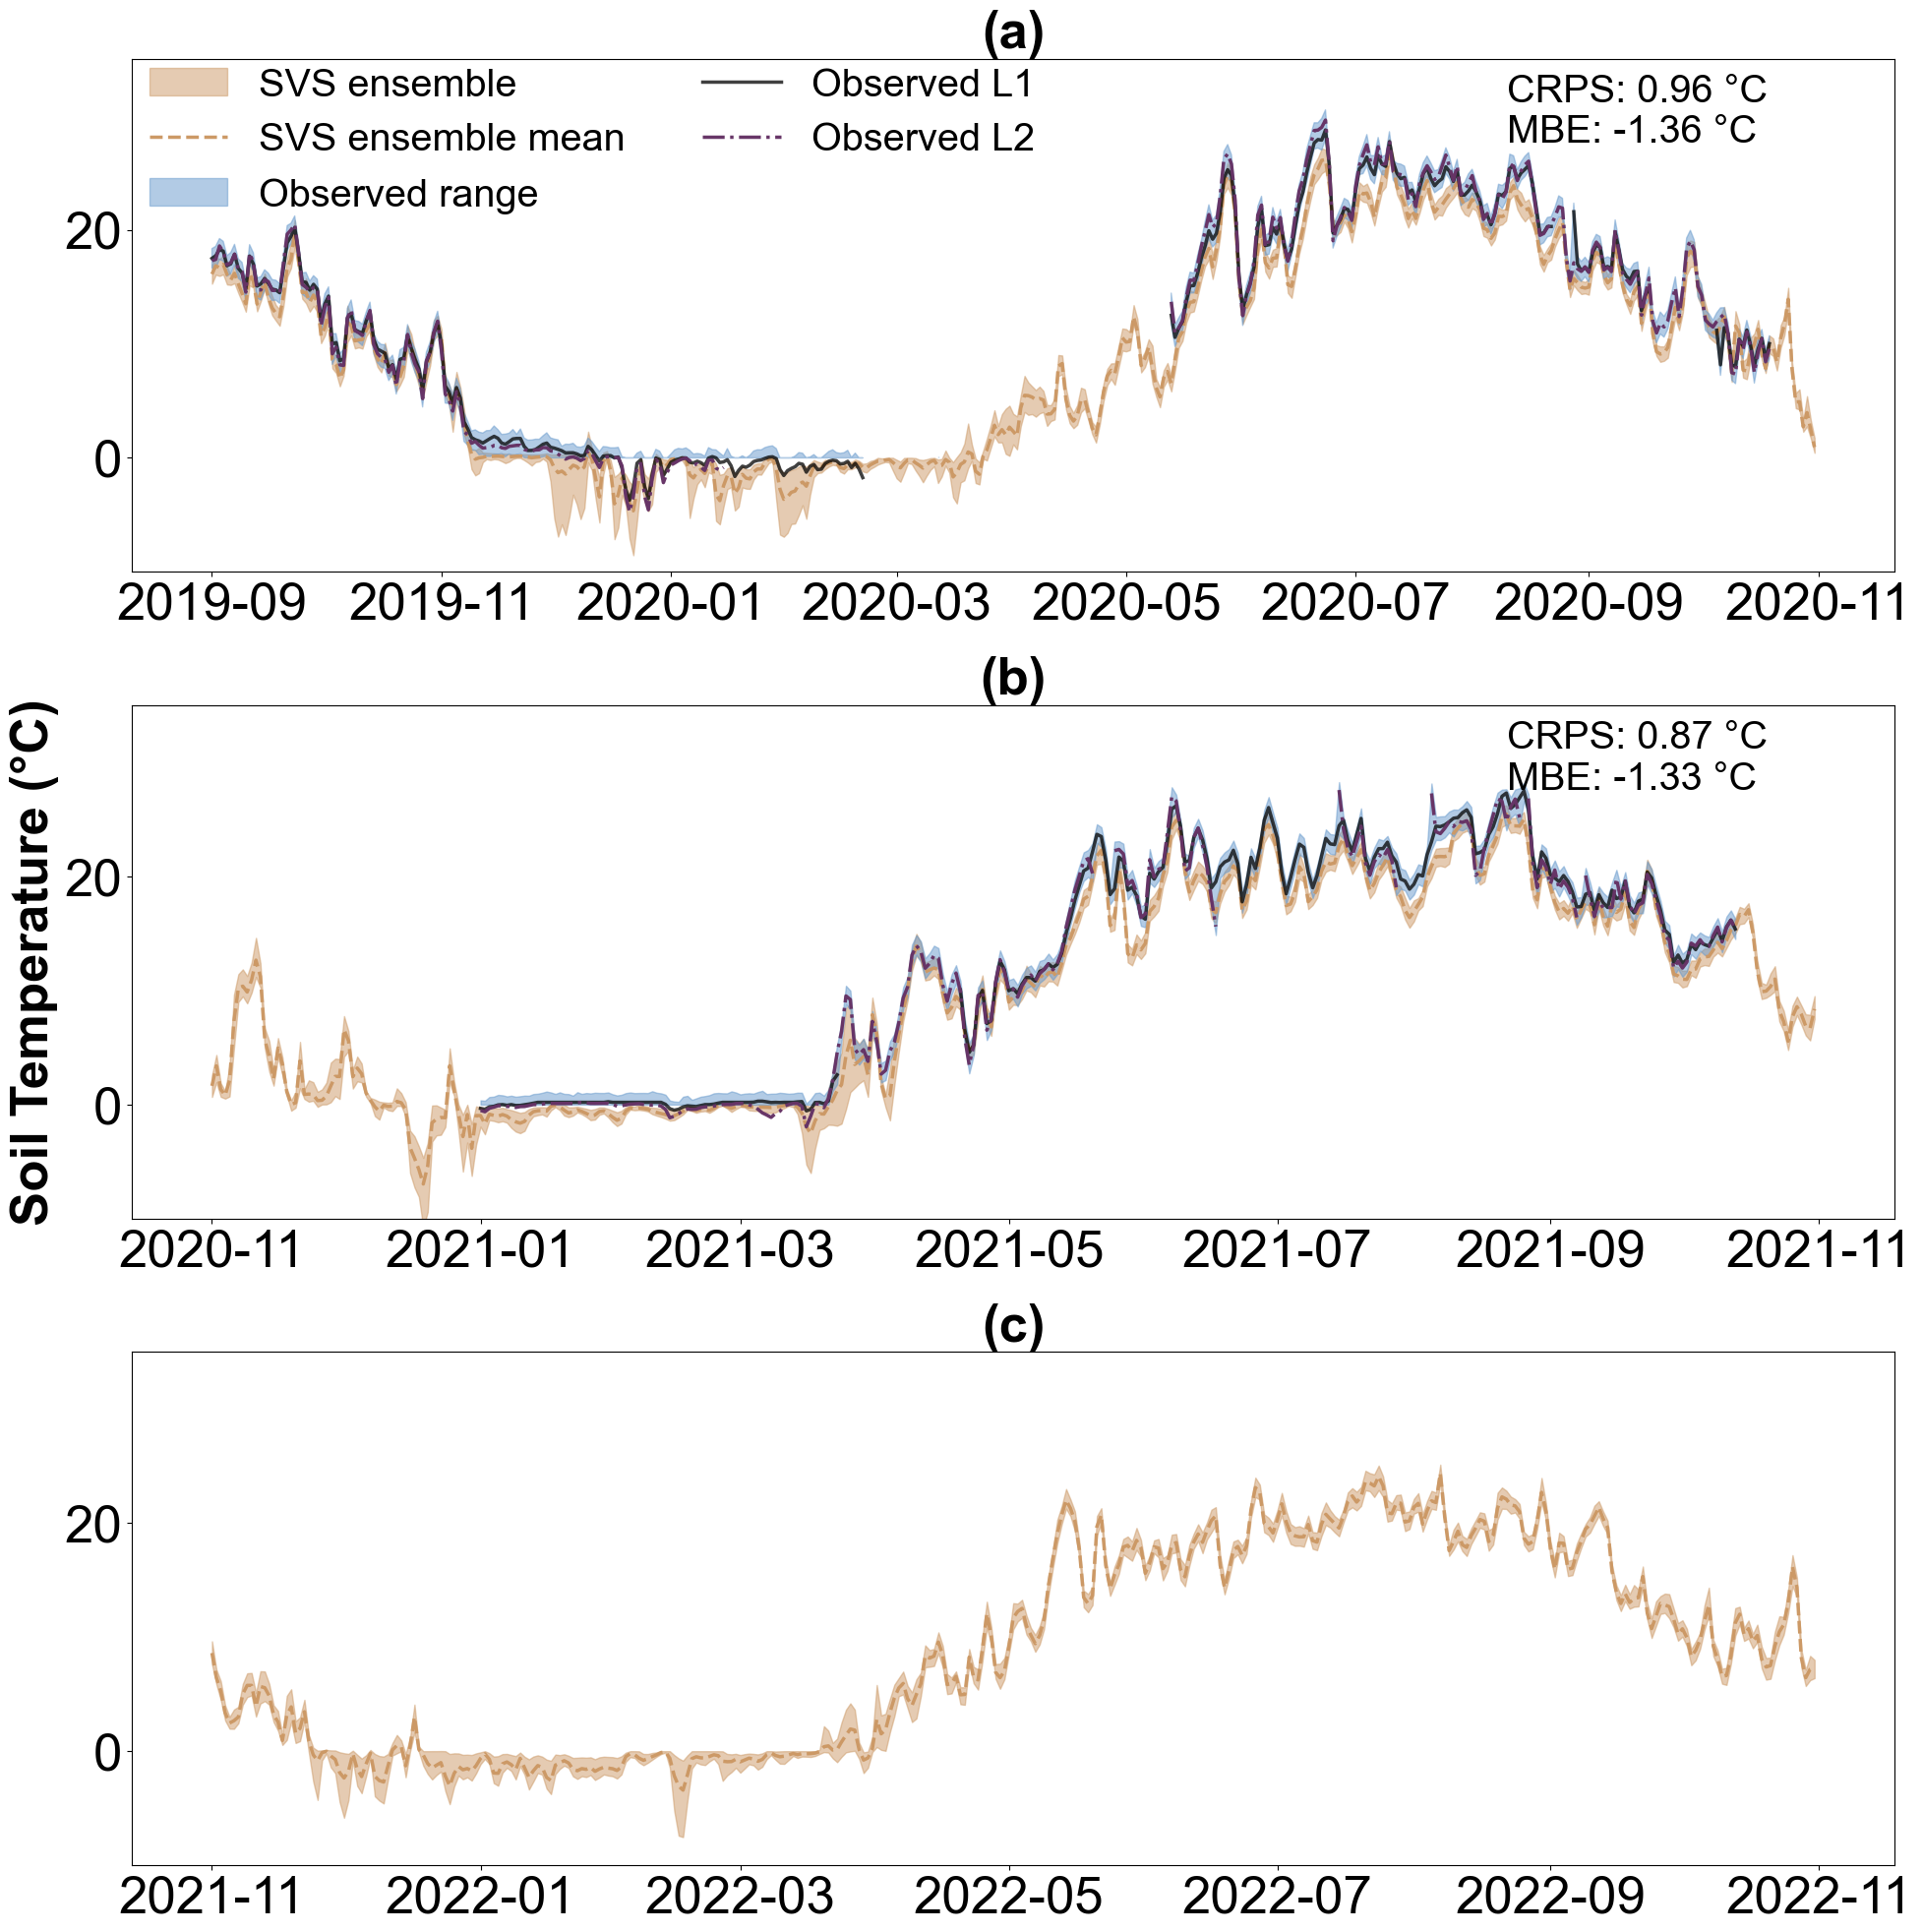

Warm months:
Slope:  0.9071, Intercept:  0.2197, R:  0.9804, p-value:  0.0000
Cold months:
Slope:  0.9949, Intercept: -1.2020, R:  0.8589  (r:  0.8589), p-value:  0.0000


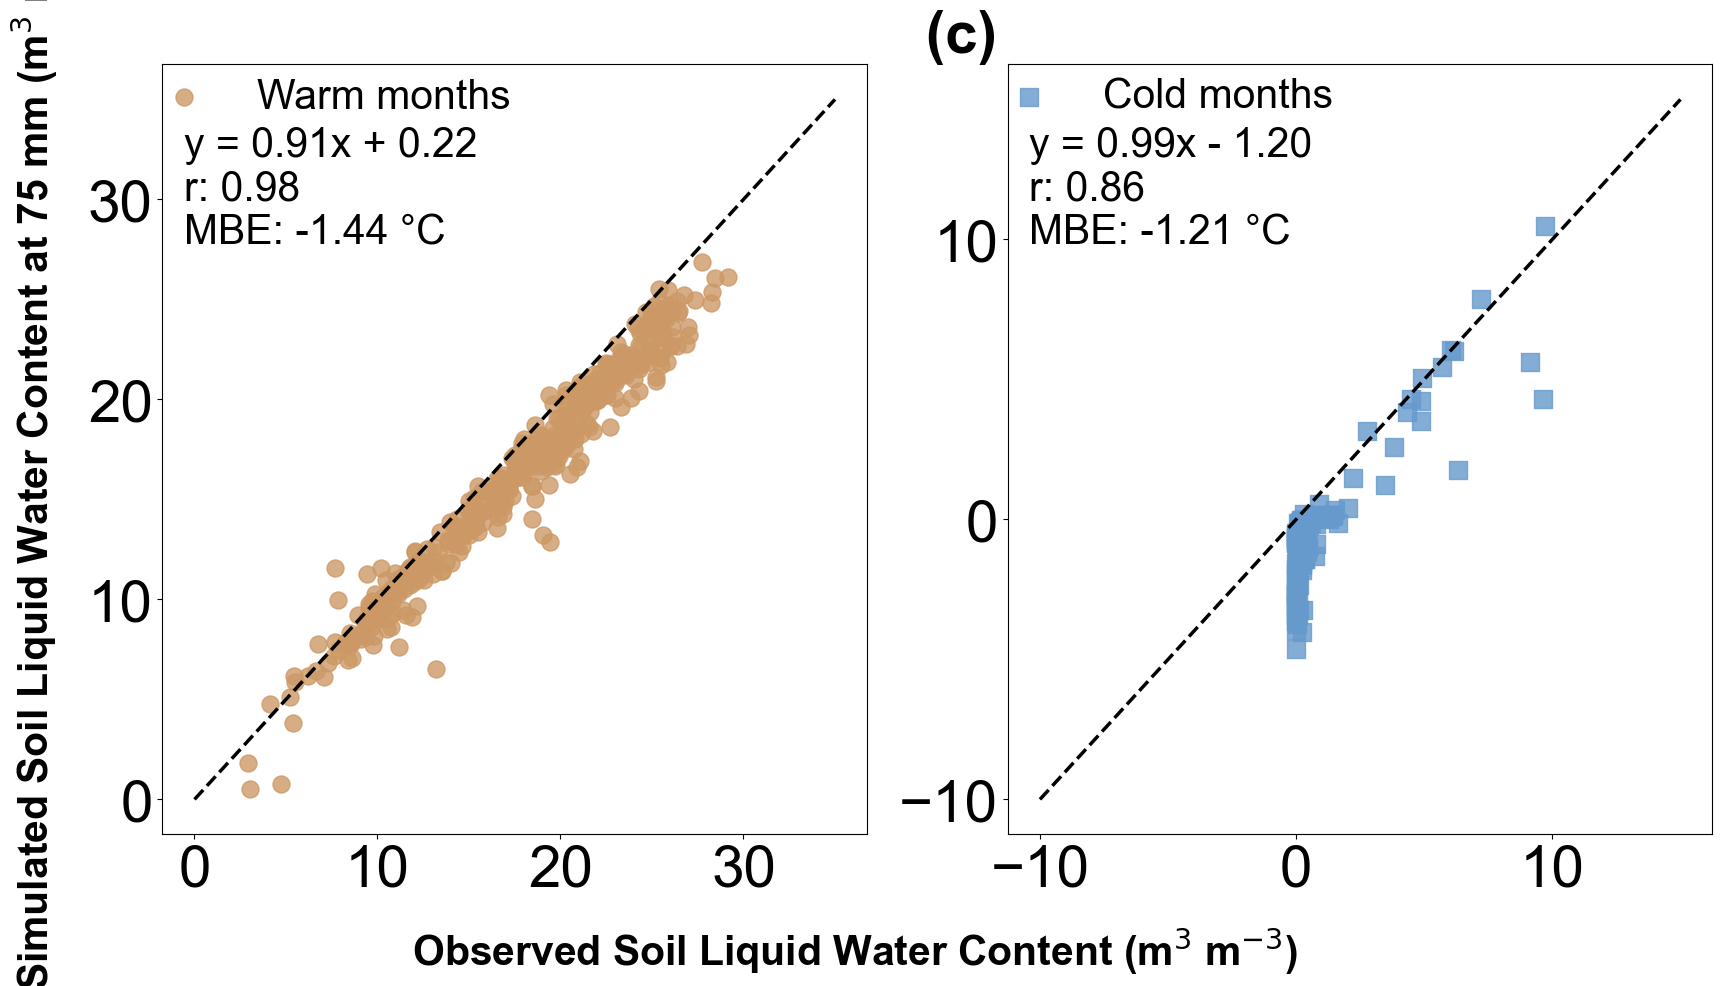

In [227]:
# observations (load and create ensemble)
drng = np.random.default_rng(RSEED)
obs_l1 = field_temp.loc[field_temp["Unique_label_"] == 'L1_75mm_ext_Temperature_degc', "Reading"].copy()
obs_l2 = field_temp.loc[field_temp["Unique_label_"] == 'L2_75mm_ext_Temperature_degc', "Reading"].copy()

## to daily
obs_l1 = obs_l1.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)
obs_l2 = obs_l2.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)

## ensemble creation
### indices where both sensors have data, only sensor 1 has data, and only sensor 2 has data
idx_both = obs_l1.dropna().index.intersection(obs_l2.dropna().index)
idx_l1 = obs_l1.dropna().index.difference(idx_both)
idx_l2 = obs_l2.dropna().index.difference(idx_both)
combined_idx = idx_both.union(idx_l1).union(idx_l2)

# create a dataframe with 2xNSAMPLE columns and
dfobs = pd.DataFrame(
    np.nan,
    index=combined_idx,
    columns=[f'obs_{i}' for i in range(2*NSAMPLE)]
)


# draw NSAMPLE samples from each sensor for the time steps where we have data from both sensors
sensor_1_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_both],
    add_value=1,
    n=NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_both],
    add_value=1,
    n=NSAMPLE, drng=drng, non_negative=True,
)

# draw 2xNSAMPLE samples from the sensor where we have data from only one sensor
sensor_1_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_l1],
    add_value=1,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_l2],
    add_value=1,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)

# fill the dataframe
dfobs.loc[idx_both, :] = np.hstack([sensor_1_sample_shared, sensor_2_sample_shared])
dfobs.loc[idx_l1, dfobs.columns[:2*NSAMPLE]] = sensor_1_sample_only
dfobs.loc[idx_l2, dfobs.columns[:2*NSAMPLE]] = sensor_2_sample_only

# load SVS model output
print('Loading SVS model output...')
ave_cols = dict(
    TPSOIL_3_4 = ["TPSOIL_3", "TPSOIL_4"]
)
dfsvs = helpers.get_ensemble_output(
    output_files, ave_cols["TPSOIL_3_4"], ave_cols=ave_cols, sub_value=273.15,
).pivot_table(
    index="date_utc", columns="member", values="TPSOIL_3_4"
).resample('1d').mean()
print('Done.')

# find shared indices between the two datasets within PERIOD_1_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_1_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2019-09-01 to 2020-11-01): {crps_neigh:.4f}')

# find shared indices between the two datasets within PERIOD_2_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_2_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2020-11-01 to 2021-11-01): {crps_neigh:.4f}')

# (There is no obs for the period 2021-11-01 to 2022-11-01)
# # find shared indices between the two datasets within PERIOD_3_D
# shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_3_D)
# print('Calculating neighborhood-based CRPS...\n')
# crps_neigh = crps_neighboor(
#     ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
#     yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
#     chunk_size=10,
#     njobs=4,
# )
# print(f'CRPS (2021-11-01 to 2022-11-01): {crps_neigh:.4f}')

# R2 and MBE for ensemble mean
print('\nCalculating R2 and MBE for ensemble mean...\n')
dfsvs_stats = dfsvs.stack().reset_index().set_index("date_utc").rename(columns={0: "DRAI"})
dfsvs_stats = dd.from_pandas(dfsvs_stats, npartitions=10)
dfsvs_stats = dfsvs_stats.groupby("date_utc")["DRAI"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

dfobs_stats = dfobs.melt(ignore_index=False, value_name='obs', var_name='sample')
dfobs_stats = dd.from_pandas(dfobs_stats, npartitions=10)
dfobs_stats = dfobs_stats.groupby("Date Time (UTC)")["obs"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

## for the entire period
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Full period: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_1_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_1_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2019-09-01 to 2020-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_2_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_2_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2020-11-01 to 2021-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# ## for PERIOD_3_D
# shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_3_D)
# r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
# mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
# print(f"2021-11-01 to 2022-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for WARM months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Warm months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for COLD months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Cold months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# Plotting (daily time series) -------------------------------------------------
# CRPS (2019-09-01 to 2020-11-01): 0.9569
# Calculating neighborhood-based CRPS...

# CRPS (2020-11-01 to 2021-11-01): 0.8672

# Calculating R2 and MBE for ensemble mean...

# Full period: R2 = 0.9931, MBE = -1.3622
# 2019-09-01 to 2020-11-01: R2 = 0.9924, MBE = -1.3857
# 2020-11-01 to 2021-11-01: R2 = 0.9940, MBE = -1.3346
# Warm months: R2 = 0.9804, MBE = -1.4386
# Cold months: R2 = 0.8589, MBE = -1.2059
FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 38,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.75,
}


SAVE_P = paths['figures_dir'] / 'DailySoilTemp75mm_ts.pdf'
FIGSIZE = (20, 20)
LWIDTH = 2.5
DPI = 2000
plt.rcParams['font.sans-serif'] = 'Arial'

fig, ax = plt.subplots(3, 1, figsize=FIGSIZE, sharey=True, sharex=False)

# for the sake of plotting, merge the two dataframes
merged_stats_perc_d = pd.merge(
    dfobs_stats, dfsvs_stats, left_index=True, right_index=True, how='outer',
    suffixes=('_obs', '_svs'),
)

# period 1
## svs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[PERIOD_1_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_1_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_1_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)

## svs ens mean
ax[0].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)

## obs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

## obs from L1
ax[0].plot(
    obs_l1.loc[PERIOD_1_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)

## obs from L2
ax[0].plot(
    obs_l2.loc[PERIOD_1_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 2
ax[1].fill_between(
    merged_stats_perc_d.loc[PERIOD_2_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_2_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_2_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[1].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[1].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

ax[1].plot(
    obs_l1.loc[PERIOD_2_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)
ax[1].plot(
    obs_l2.loc[PERIOD_2_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 3
ax[2].fill_between(
    merged_stats_perc_d.loc[PERIOD_3_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_3_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_3_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[2].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[2].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)
# ax[2].plot(
#     obs_l1.loc[PERIOD_3_D],
#     color='black', label='Observed L1', linewidth=LWIDTH,
#     linestyle='-', alpha=0.75,
# )
# ax[2].plot(
#     obs_l2.loc[PERIOD_3_D],
#     color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
#     linestyle='-.', alpha=0.99,
# )


# format
ax[0].set_title('(a)', fontdict=FONT)
ax[1].set_title('(b)', fontdict=FONT)
ax[2].set_title('(c)', fontdict=FONT)

for i in range(3):
    ax[i].set_ylabel('', fontdict=FONT)
    ax[i].set_xlabel('', fontdict=FONT)
    ax[i].tick_params(axis='both', which='major', labelsize=FONT['size'])
    ax[i].tick_params(axis='both', which='minor', labelsize=FONT['size'])
    ax[i].legend([], frameon=False)
    ax[i].set_ylim(-10, 35)

ax[0].legend(
    loc='upper left', fontsize=SFONT['size'], frameon=False,
    ncol=2,
    bbox_to_anchor=(-0.01, 1.05),
)
# mm.d-1
ax[1].set_ylabel('Soil Temperature (°C)', fontdict=FONT)
crps_ns = [0.9569, 0.8672]
MBE_s = [-1.3622, -1.3346]
for i in range(2):
    ax[i].annotate(
        f'CRPS: {crps_ns[i]:.2f} °C \nMBE: {MBE_s[i]:.2f} °C',
        xy=(0.78, 0.97), xycoords='axes fraction',
        fontsize=SFONT['size'], ha='left', va='top',
        # no background
    )

plt.tight_layout(pad=2.0)
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()

# Scatter plot -----------------------------------------------------------------
# Warm months:
# Slope:  0.9071, Intercept:  0.2197, R:  0.9804, p-value:  0.0000
# Cold months:
# Slope:  0.9949, Intercept: -1.2020, R:  0.8589  (r:  0.8589), p-value:  0.0000
SAVE_P = paths['figures_dir'] / 'DailySoilTemp75mm_scatter.pdf'

FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 42,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.7,
}

FIGSIZE = (20, 10)
MKSIZE = 150

fig, ax = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False, sharex=False)

# warm months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
ax[0].scatter(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=GOLD_BROWN, label='Warm months', s=MKSIZE, alpha=0.8, marker='o',
)

# cold months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
ax[1].scatter(
    x= merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y= merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=LIGHT_BLUE, label='Cold months', s=MKSIZE, alpha=0.8, marker='s',
)

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Warm months:')
print(f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f}, p-value: {p_value: .4f}')

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Cold months:')
print(
    f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f} '
    f' (r: {r_value: .4f}), p-value: {p_value: .4f}'
)

# format
for ax_ in ax:
    ax_.legend(
        loc='upper left', fontsize=SFONT['size'],
        frameon=False, framealpha=0.2,
        bbox_to_anchor=(-0.08, 1.03)
    )
    ax_.tick_params(axis='both', which='major', labelsize=FONT['size'])

ax[0].set_xlabel(
    60 * ' ' + 'Observed Soil Liquid Water Content (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_ylabel(
    'Simulated Soil Liquid Water Content at 75 mm (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_title(55 * ' ' + '(c)', fontdict=FONT)

# 1:1 line,  for both
ax[0].plot([0.00, 35], [0.00, 35], color='black', linestyle='--', linewidth=LWIDTH)
ax[0].set_yticks([0.00, 10, 20, 30])

# 1:1 line,
ax[1].plot([-10, 15], [-10, 15], color='black', linestyle='--', linewidth=LWIDTH)
ax[1].set_yticks([-10, 0, 10])

ax[0].annotate(
    f'y = 0.91x + 0.22\nr: 0.98\nMBE: -1.44 °C',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# cold
ax[1].annotate(
    f'y = 0.99x - 1.20\nr: 0.86\nMBE: -1.21 °C',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# save
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()


## 75 mm soil volumetruc liquid water content

Loading SVS model output...
Done.
Calculating neighborhood-based CRPS...

CRPS (2019-09-01 to 2020-11-01): 0.0155
Calculating neighborhood-based CRPS...

CRPS (2020-11-01 to 2021-11-01): 0.0248

Calculating R2 and MBE for ensemble mean...

Full period: R2 = 0.6633, MBE = -0.0123
2019-09-01 to 2020-11-01: R2 = 0.7640, MBE = -0.0104
2020-11-01 to 2021-11-01: R2 = 0.5203, MBE = -0.0145
Warm months: R2 = 0.8034, MBE = 0.0102
Cold months: R2 = 0.8640, MBE = -0.0582


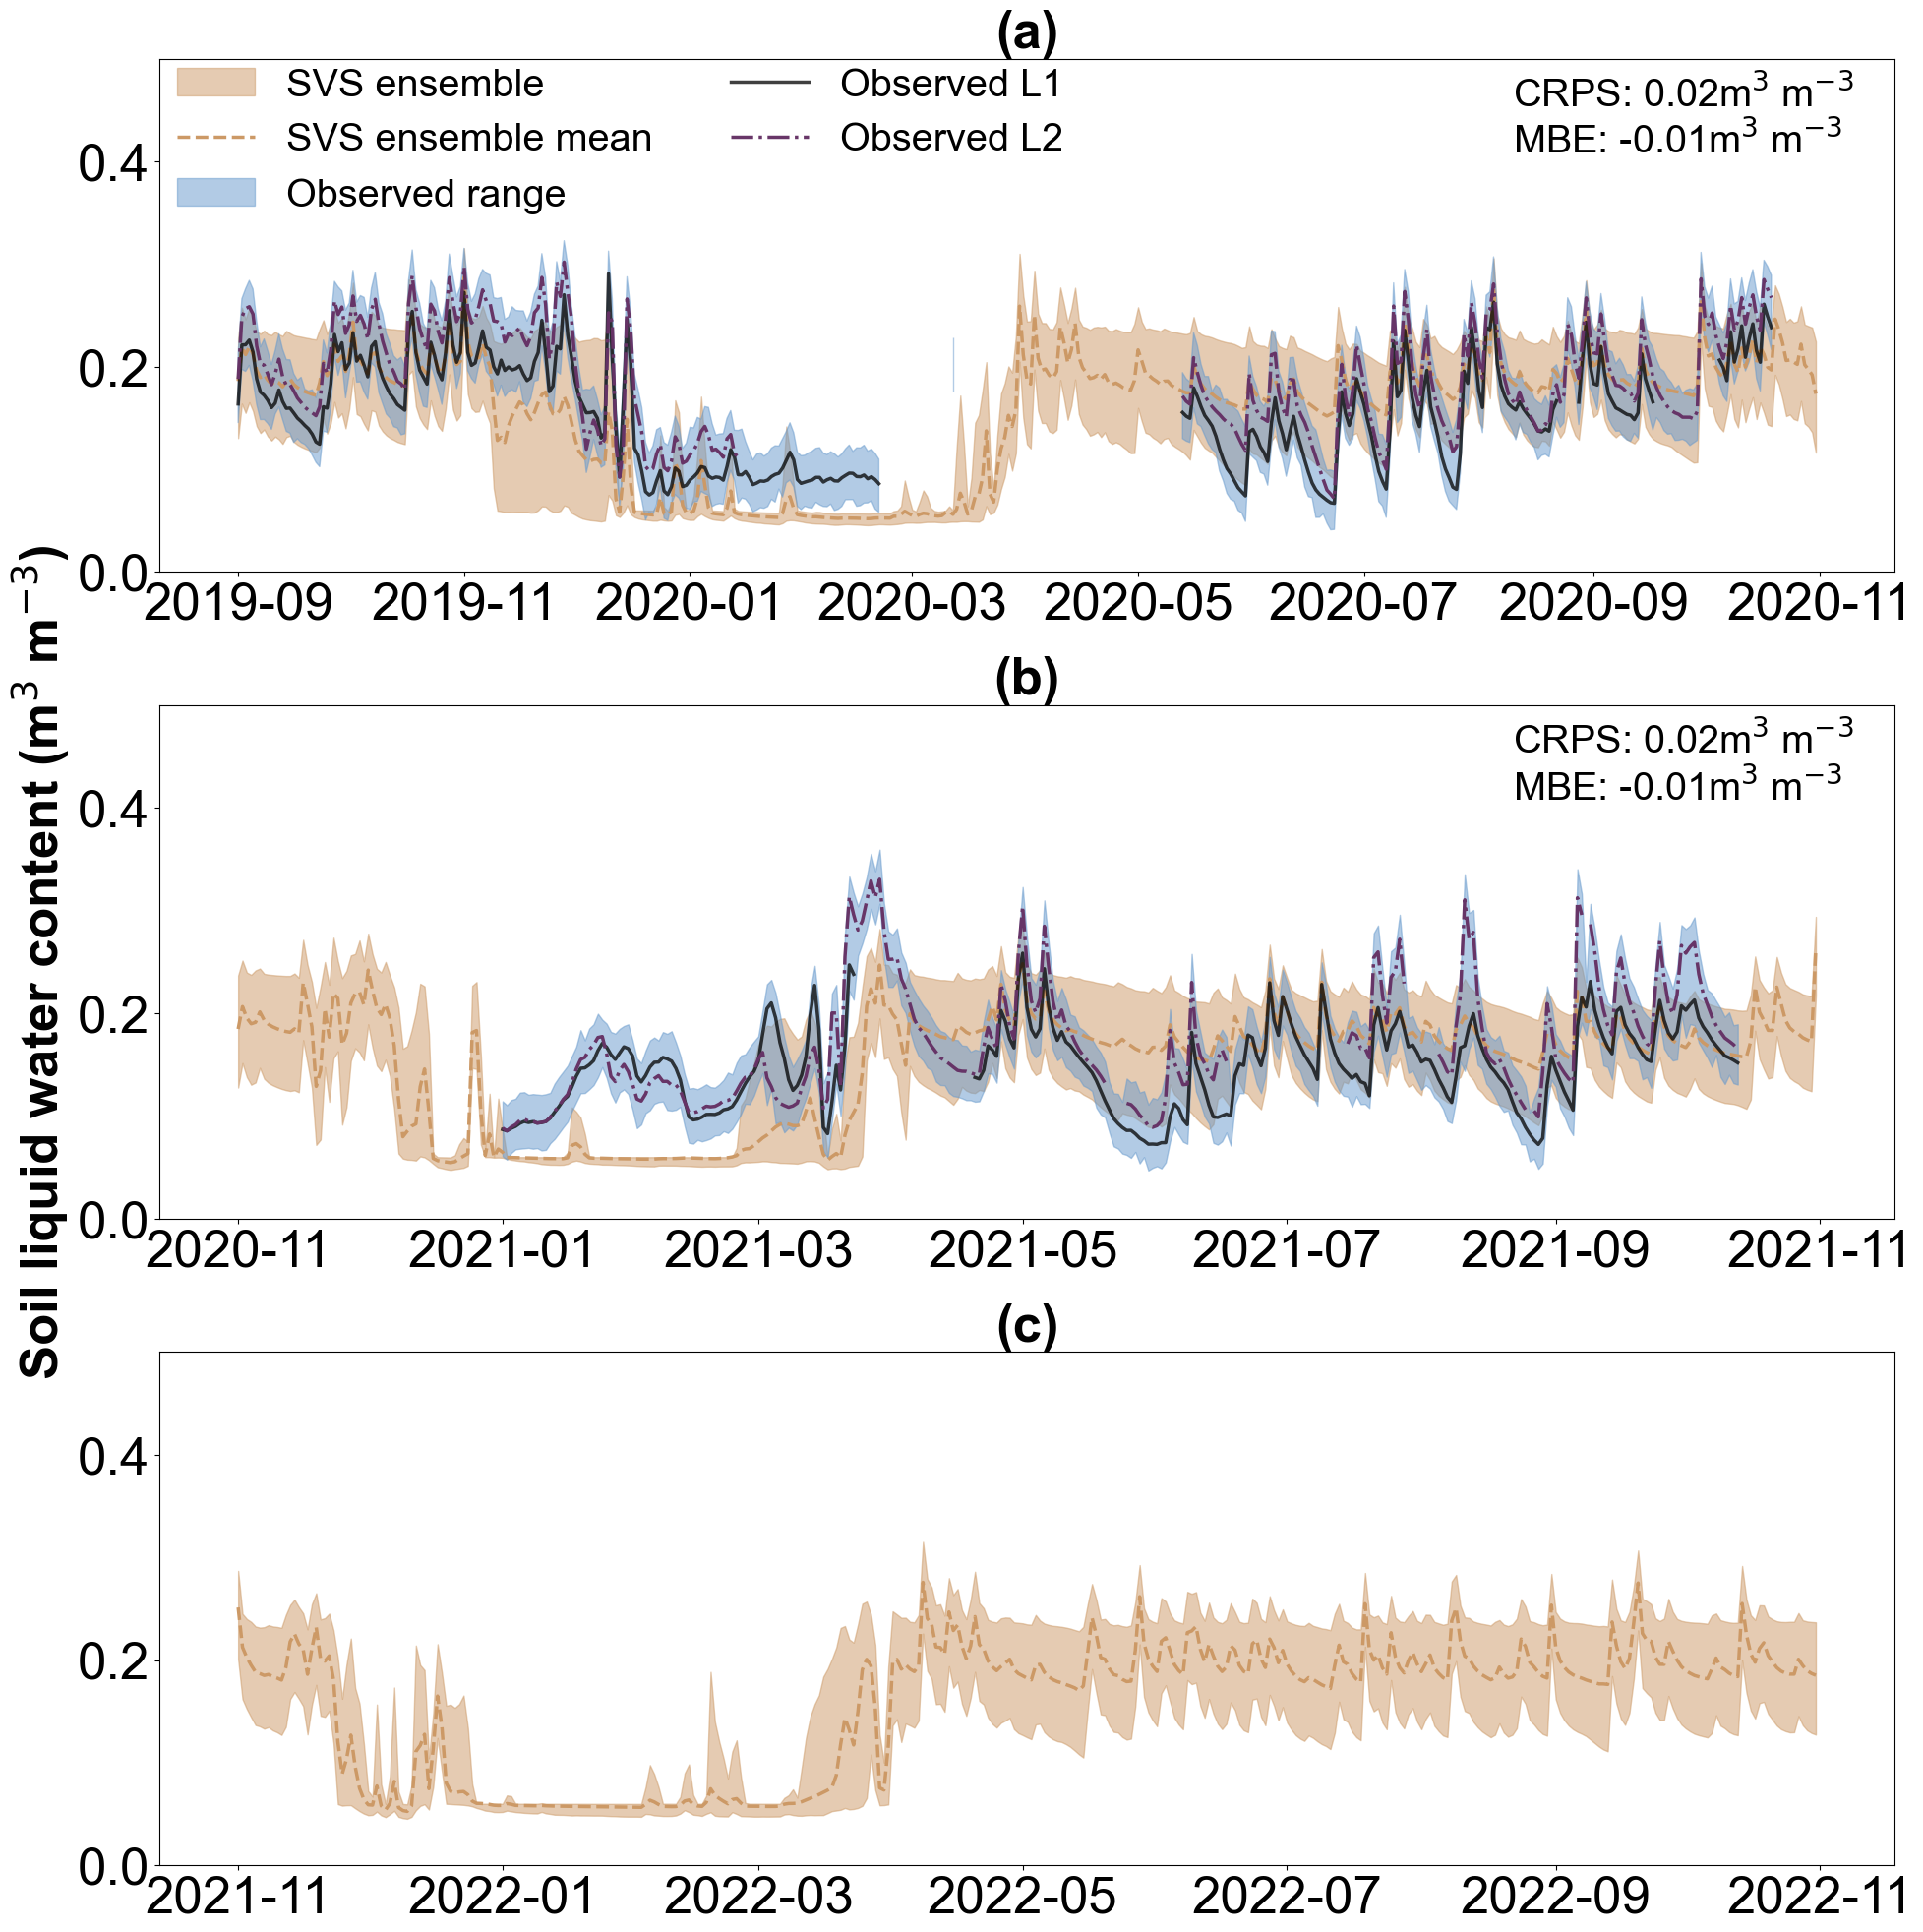

Warm months:
Slope:  0.3636, Intercept:  0.1216, R:  0.8034, p-value:  0.0000
Cold months:
Slope:  0.7036, Intercept: -0.0148, R:  0.8640  (r:  0.8640), p-value:  0.0000


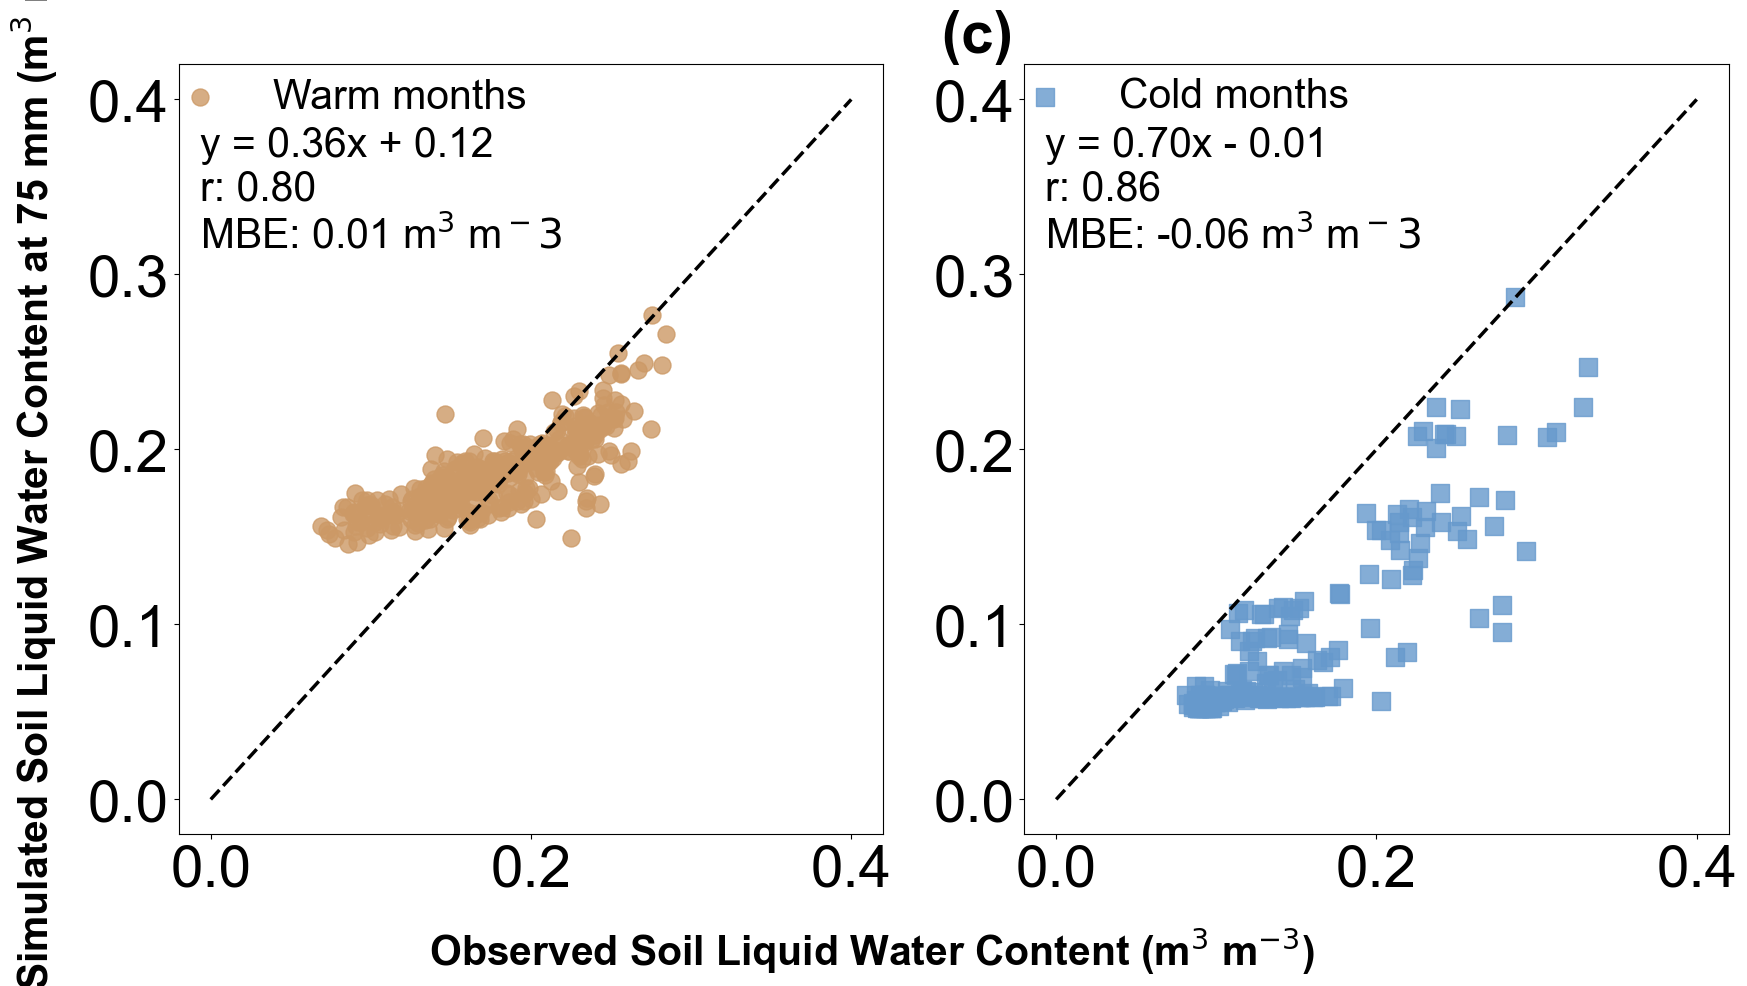

In [221]:
# observations (load and create ensemble)
drng = np.random.default_rng(RSEED)
obs_l1 = field_moist.loc[field_moist["Unique_label_"] == 'L1_75mm_ext_Moisture_percent', "Reading"].copy()
obs_l2 = field_moist.loc[field_moist["Unique_label_"] == 'L2_75mm_ext_Moisture_percent', "Reading"].copy()

## to daily
obs_l1 = obs_l1.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)
obs_l2 = obs_l2.resample('1d').agg(
    lambda x: np.mean(x) if not np.all(np.isnan(x)) else np.nan
)

## ensemble creation
### indices where both sensors have data, only sensor 1 has data, and only sensor 2 has data
idx_both = obs_l1.dropna().index.intersection(obs_l2.dropna().index)
idx_l1 = obs_l1.dropna().index.difference(idx_both)
idx_l2 = obs_l2.dropna().index.difference(idx_both)
combined_idx = idx_both.union(idx_l1).union(idx_l2)

# create a dataframe with 2xNSAMPLE columns and
dfobs = pd.DataFrame(
    np.nan,
    index=combined_idx,
    columns=[f'obs_{i}' for i in range(2*NSAMPLE)]
)


# draw NSAMPLE samples from each sensor for the time steps where we have data from both sensors
sensor_1_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_both],
    add_value=0.03,
    n=NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_shared = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_both],
    add_value=0.03,
    n=NSAMPLE, drng=drng, non_negative=True,
)

# draw 2xNSAMPLE samples from the sensor where we have data from only one sensor
sensor_1_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l1.loc[idx_l1],
    add_value=0.03,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)
sensor_2_sample_only = helpers.uniform_sample_from_obs(
    obs_series=obs_l2.loc[idx_l2],
    add_value=0.03,
    n=2*NSAMPLE, drng=drng, non_negative=True,
)

# fill the dataframe
dfobs.loc[idx_both, :] = np.hstack([sensor_1_sample_shared, sensor_2_sample_shared])
dfobs.loc[idx_l1, dfobs.columns[:2*NSAMPLE]] = sensor_1_sample_only
dfobs.loc[idx_l2, dfobs.columns[:2*NSAMPLE]] = sensor_2_sample_only

# load SVS model output
print('Loading SVS model output...')
ave_cols = dict(
    WSOIL_3_4 = ["WSOIL_3", "WSOIL_4"]
)
dfsvs = helpers.get_ensemble_output(
    output_files, ave_cols["WSOIL_3_4"], ave_cols=ave_cols
).pivot_table(
    index="date_utc", columns="member", values="WSOIL_3_4"
).resample('1d').mean()
print('Done.')

# find shared indices between the two datasets within PERIOD_1_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_1_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2019-09-01 to 2020-11-01): {crps_neigh:.4f}')

# find shared indices between the two datasets within PERIOD_2_D
shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_2_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
    yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2020-11-01 to 2021-11-01): {crps_neigh:.4f}')

# (There is no obs for the period 2021-11-01 to 2022-11-01)
# # find shared indices between the two datasets within PERIOD_3_D
# shared_idx = dfobs.index.intersection(dfsvs.index).intersection(PERIOD_3_D)
# print('Calculating neighborhood-based CRPS...\n')
# crps_neigh = crps_neighboor(
#     ens=dfsvs.loc[shared_idx, :].values.astype(np.float32),
#     yobs=dfobs.loc[shared_idx, :].values.astype(np.float32),
#     chunk_size=10,
#     njobs=4,
# )
# print(f'CRPS (2021-11-01 to 2022-11-01): {crps_neigh:.4f}')

# R2 and MBE for ensemble mean
print('\nCalculating R2 and MBE for ensemble mean...\n')
dfsvs_stats = dfsvs.stack().reset_index().set_index("date_utc").rename(columns={0: "DRAI"})
dfsvs_stats = dd.from_pandas(dfsvs_stats, npartitions=10)
dfsvs_stats = dfsvs_stats.groupby("date_utc")["DRAI"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

dfobs_stats = dfobs.melt(ignore_index=False, value_name='obs', var_name='sample')
dfobs_stats = dd.from_pandas(dfobs_stats, npartitions=10)
dfobs_stats = dfobs_stats.groupby("Date Time (UTC)")["obs"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

## for the entire period
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Full period: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_1_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_1_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2019-09-01 to 2020-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_2_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_2_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"2020-11-01 to 2021-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# ## for PERIOD_3_D
# shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_3_D)
# r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
# mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
# print(f"2021-11-01 to 2022-11-01: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for WARM months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Warm months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for COLD months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Cold months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

# Plotting (daily time series) -------------------------------------------------
FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 38,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.75,
}


SAVE_P = paths['figures_dir'] / 'DailySoilMoist75mm_ts.pdf'
FIGSIZE = (20, 20)
LWIDTH = 2.5
DPI = 2000
plt.rcParams['font.sans-serif'] = 'Arial'

fig, ax = plt.subplots(3, 1, figsize=FIGSIZE, sharey=True, sharex=False)

# for the sake of plotting, merge the two dataframes
merged_stats_perc_d = pd.merge(
    dfobs_stats, dfsvs_stats, left_index=True, right_index=True, how='outer',
    suffixes=('_obs', '_svs'),
)

# period 1
## svs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[PERIOD_1_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_1_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_1_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)

## svs ens mean
ax[0].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)

## obs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

## obs from L1
ax[0].plot(
    obs_l1.loc[PERIOD_1_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)

## obs from L2
ax[0].plot(
    obs_l2.loc[PERIOD_1_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 2
ax[1].fill_between(
    merged_stats_perc_d.loc[PERIOD_2_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_2_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_2_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[1].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[1].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

ax[1].plot(
    obs_l1.loc[PERIOD_2_D],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)
ax[1].plot(
    obs_l2.loc[PERIOD_2_D],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 3
ax[2].fill_between(
    merged_stats_perc_d.loc[PERIOD_3_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_3_D, '5%_svs'],
    merged_stats_perc_d.loc[PERIOD_3_D, '95%_svs'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[2].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[2].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '5%_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), '95%_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)
# ax[2].plot(
#     obs_l1.loc[PERIOD_3_D],
#     color='black', label='Observed L1', linewidth=LWIDTH,
#     linestyle='-', alpha=0.75,
# )
# ax[2].plot(
#     obs_l2.loc[PERIOD_3_D],
#     color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
#     linestyle='-.', alpha=0.99,
# )


# format
ax[0].set_title('(a)', fontdict=FONT)
ax[1].set_title('(b)', fontdict=FONT)
ax[2].set_title('(c)', fontdict=FONT)

for i in range(3):
    ax[i].set_ylabel('', fontdict=FONT)
    ax[i].set_xlabel('', fontdict=FONT)
    ax[i].tick_params(axis='both', which='major', labelsize=FONT['size'])
    ax[i].tick_params(axis='both', which='minor', labelsize=FONT['size'])
    ax[i].legend([], frameon=False)
    ax[i].set_ylim(0, 0.5)

ax[0].legend(
    loc='upper left', fontsize=SFONT['size'], frameon=False,
    ncol=2,
    bbox_to_anchor=(-0.01, 1.05),
)
# mm.d-1
ax[1].set_ylabel('Soil liquid water content (m$^3$ m$^{-3}$)', fontdict=FONT)
crps_ns = [0.0155, 0.0248]
MBE_s = [-0.0104, -0.0145]
for i in range(2):
    ax[i].annotate(
        f'CRPS: {crps_ns[i]:.2f}' + 'm$^3$ m$^{-3}$' + '\n' + f'MBE: {MBE_s[i]:.2f}' + 'm$^3$ m$^{-3}$',
        xy=(0.78, 0.97), xycoords='axes fraction',
        fontsize=SFONT['size'], ha='left', va='top',
        # no background
    )

plt.tight_layout(pad=2.0)
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()

# Scatter plot -----------------------------------------------------------------
SAVE_P = paths['figures_dir'] / 'DailySoilMoist75mm_scatter.pdf'

FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 42,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.7,
}

FIGSIZE = (20, 10)
MKSIZE = 150

fig, ax = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False, sharex=False)

# warm months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
ax[0].scatter(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=GOLD_BROWN, label='Warm months', s=MKSIZE, alpha=0.8, marker='o',
)

# cold months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
ax[1].scatter(
    x= merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y= merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=LIGHT_BLUE, label='Cold months', s=MKSIZE, alpha=0.8, marker='s',
)

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Warm months:')
print(f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f}, p-value: {p_value: .4f}')

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Cold months:')
print(
    f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f} '
    f' (r: {r_value: .4f}), p-value: {p_value: .4f}'
)

# format
for ax_ in ax:
    ax_.legend(
        loc='upper left', fontsize=SFONT['size'],
        frameon=False, framealpha=0.2,
        bbox_to_anchor=(-0.08, 1.03)
    )
    ax_.tick_params(axis='both', which='major', labelsize=FONT['size'])

ax[0].set_xlabel(
    60 * ' ' + 'Observed Soil Liquid Water Content (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_ylabel(
    'Simulated Soil Liquid Water Content at 75 mm (m$^3$ m$^{-3}$)', fontdict=SFONT, labelpad=20,
)
ax[0].set_title(55 * ' ' + '(c)', fontdict=FONT)

# 1:1 line,  for both
ax[0].plot([0.00, 0.4], [0.00, 0.4], color='black', linestyle='--', linewidth=LWIDTH)
ax[0].set_yticks([0.00, 0.1, 0.2, 0.3, 0.4])

# 1:1 line,
ax[1].plot([0.00, 0.4], [0.00, 0.4], color='black', linestyle='--', linewidth=LWIDTH)
ax[1].set_yticks([0.00, 0.1, 0.2, 0.3, 0.4])

# annotate with slope and intercept
# Warm months:
# Slope:  0.3636, Intercept:  0.1216, R:  0.8034, p-value:  0.0000
# Cold months:
# Slope:  0.7036, Intercept: -0.0148, R:  0.8640  (r:  0.8640), p-value:  0.0000
# Warm months: R2 = 0.8034, MBE = 0.0102
# Cold months: R2 = 0.8640, MBE = -0.0582
# warm
ax[0].annotate(
    f'y = 0.36x + 0.12\nr: 0.80\nMBE: 0.01 m$^3$ m$^{-3}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# cold
ax[1].annotate(
    f'y = 0.70x - 0.01\nr: 0.86\nMBE: -0.06 m$^3$ m$^{-3}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# save
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()


## Deep percolation

Loading SVS deep percolation output ...
Done.
Calculating neighborhood-based CRPS...

CRPS (2019-09-01 to 2020-11-01): 0.6152
Calculating neighborhood-based CRPS...

CRPS (2020-11-01 to 2021-11-01): 0.1734
Calculating neighborhood-based CRPS...

CRPS (2021-11-01 to 2022-11-01): 0.8114
Full period: R2 = 0.4344, MBE = -0.4600
Period 1: R2 = 0.5989, MBE = -0.2354
Period 2: R2 = 0.3859, MBE = -0.2108
Period 3: R2 = 0.1758, MBE = -1.4541
Warm months: R2 = 0.6207, MBE = -0.3072
Cold months: R2 = 0.3401, MBE = -0.7711


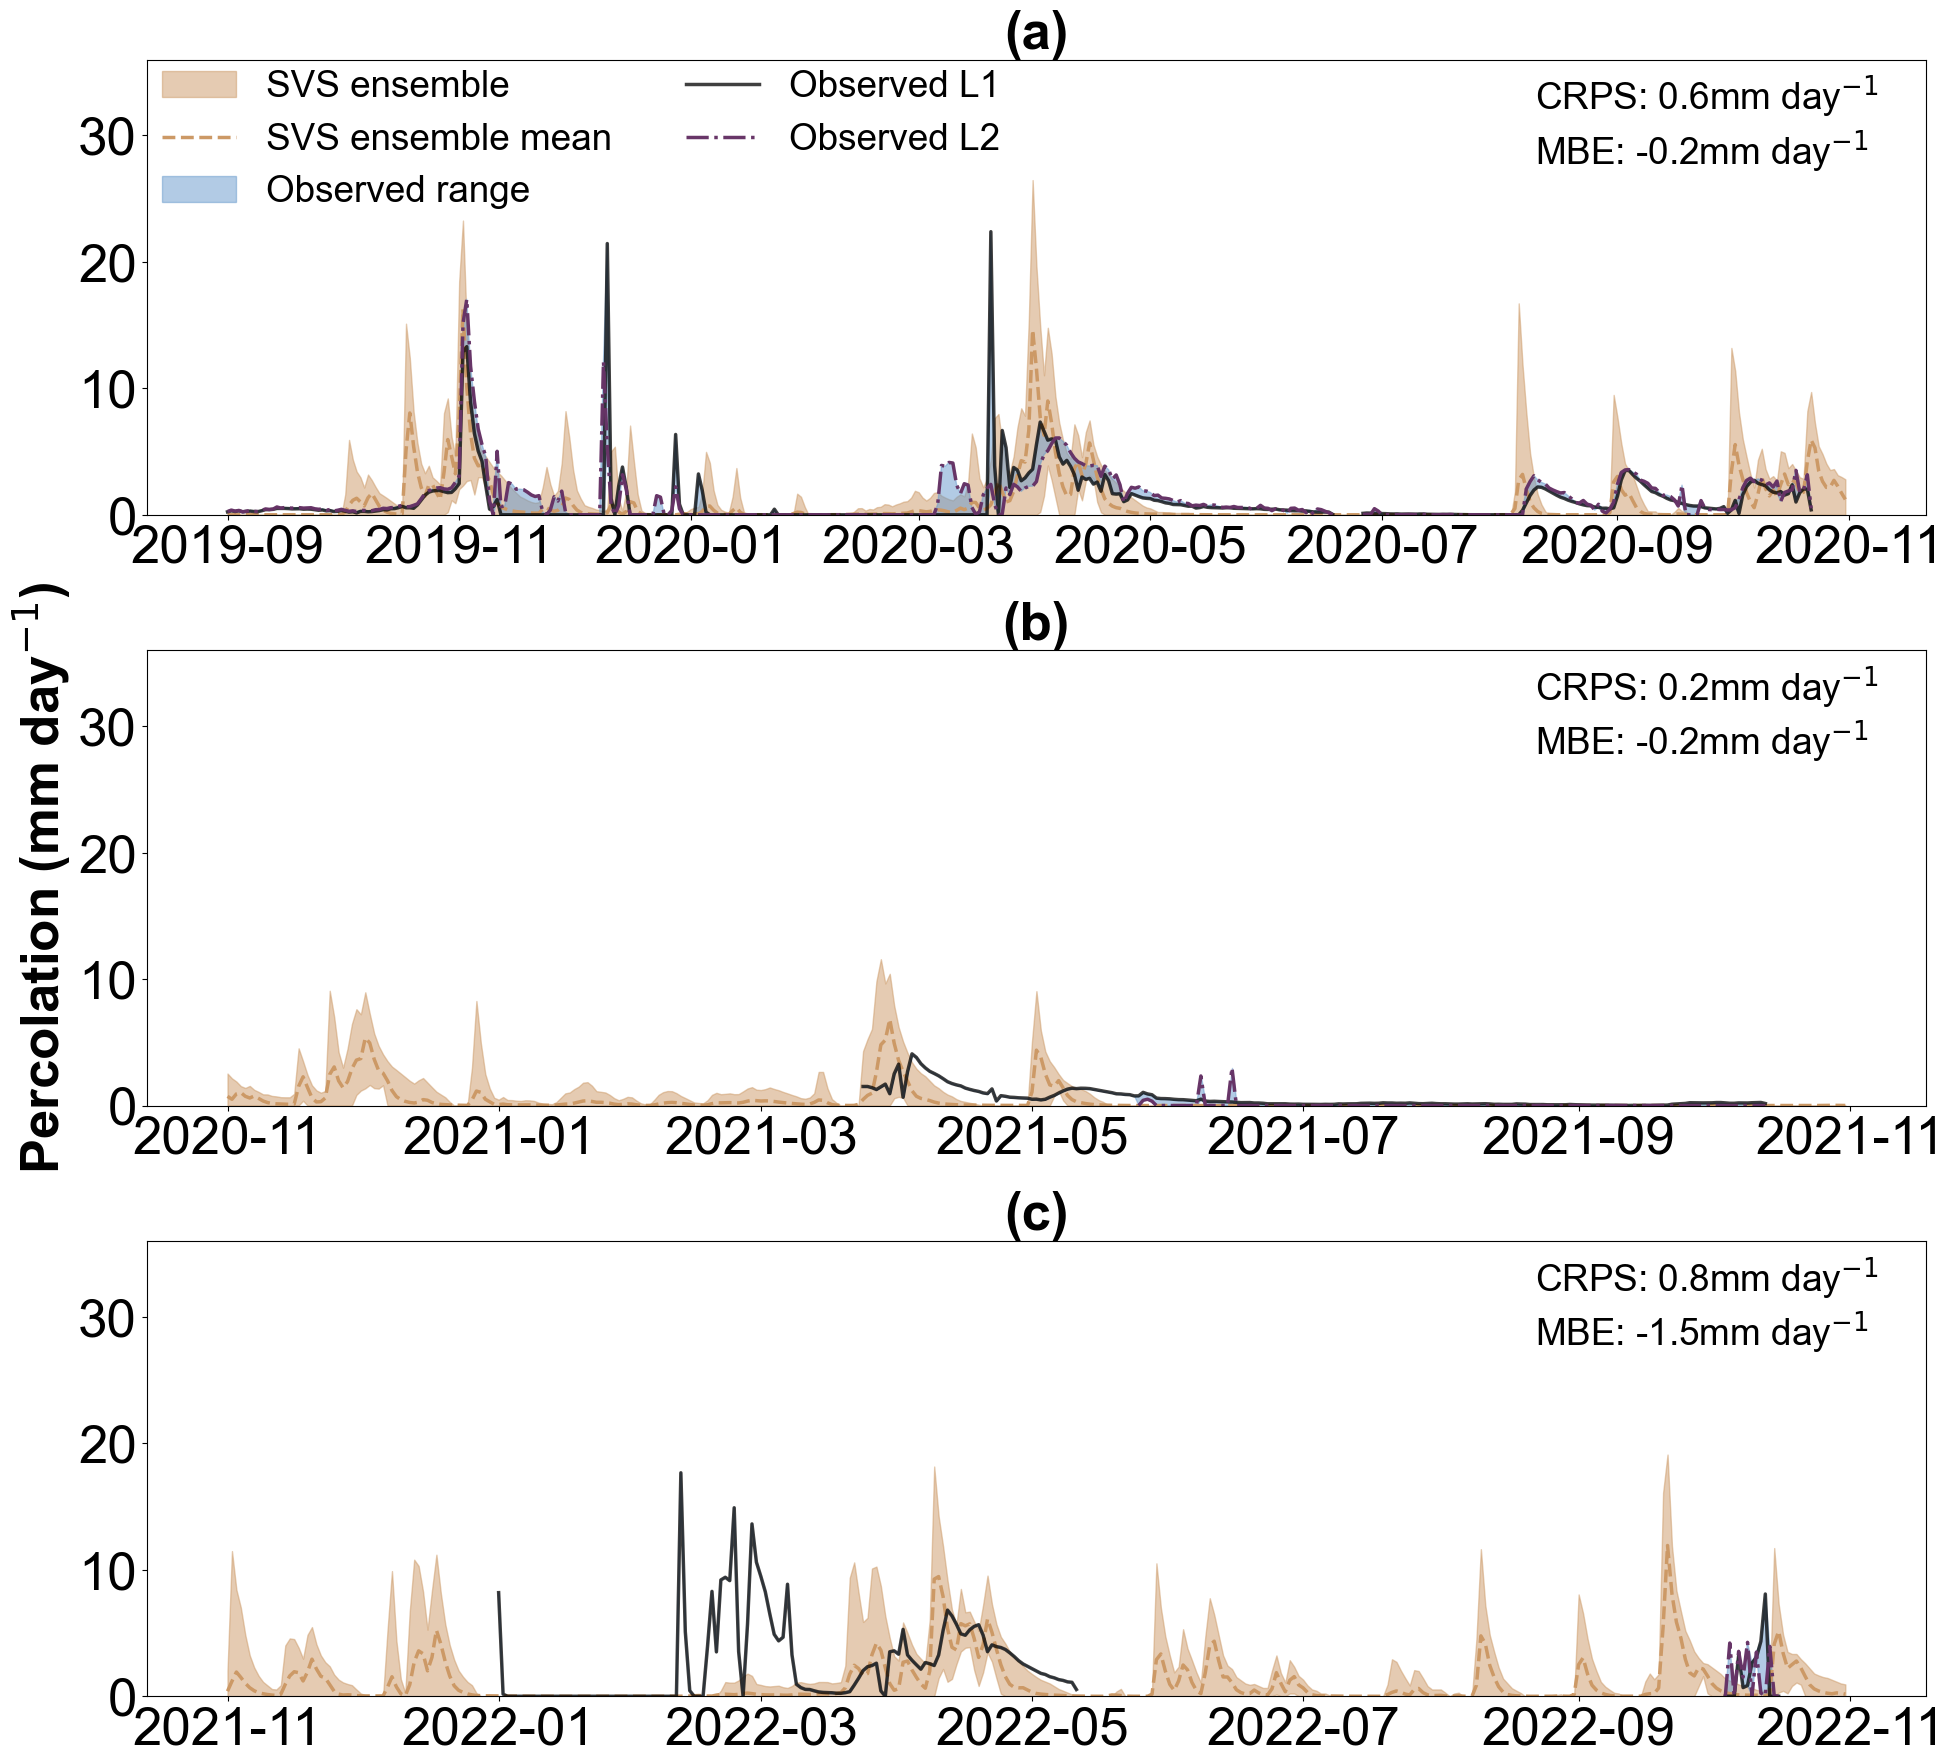

Warm months:
Slope:  0.7691, Intercept: -0.0622, R:  0.6207, p-value:  0.0000
Cold months:
Slope:  0.2133, Intercept:  0.4359, R:  0.3401  (r:  0.3401), p-value:  0.0000


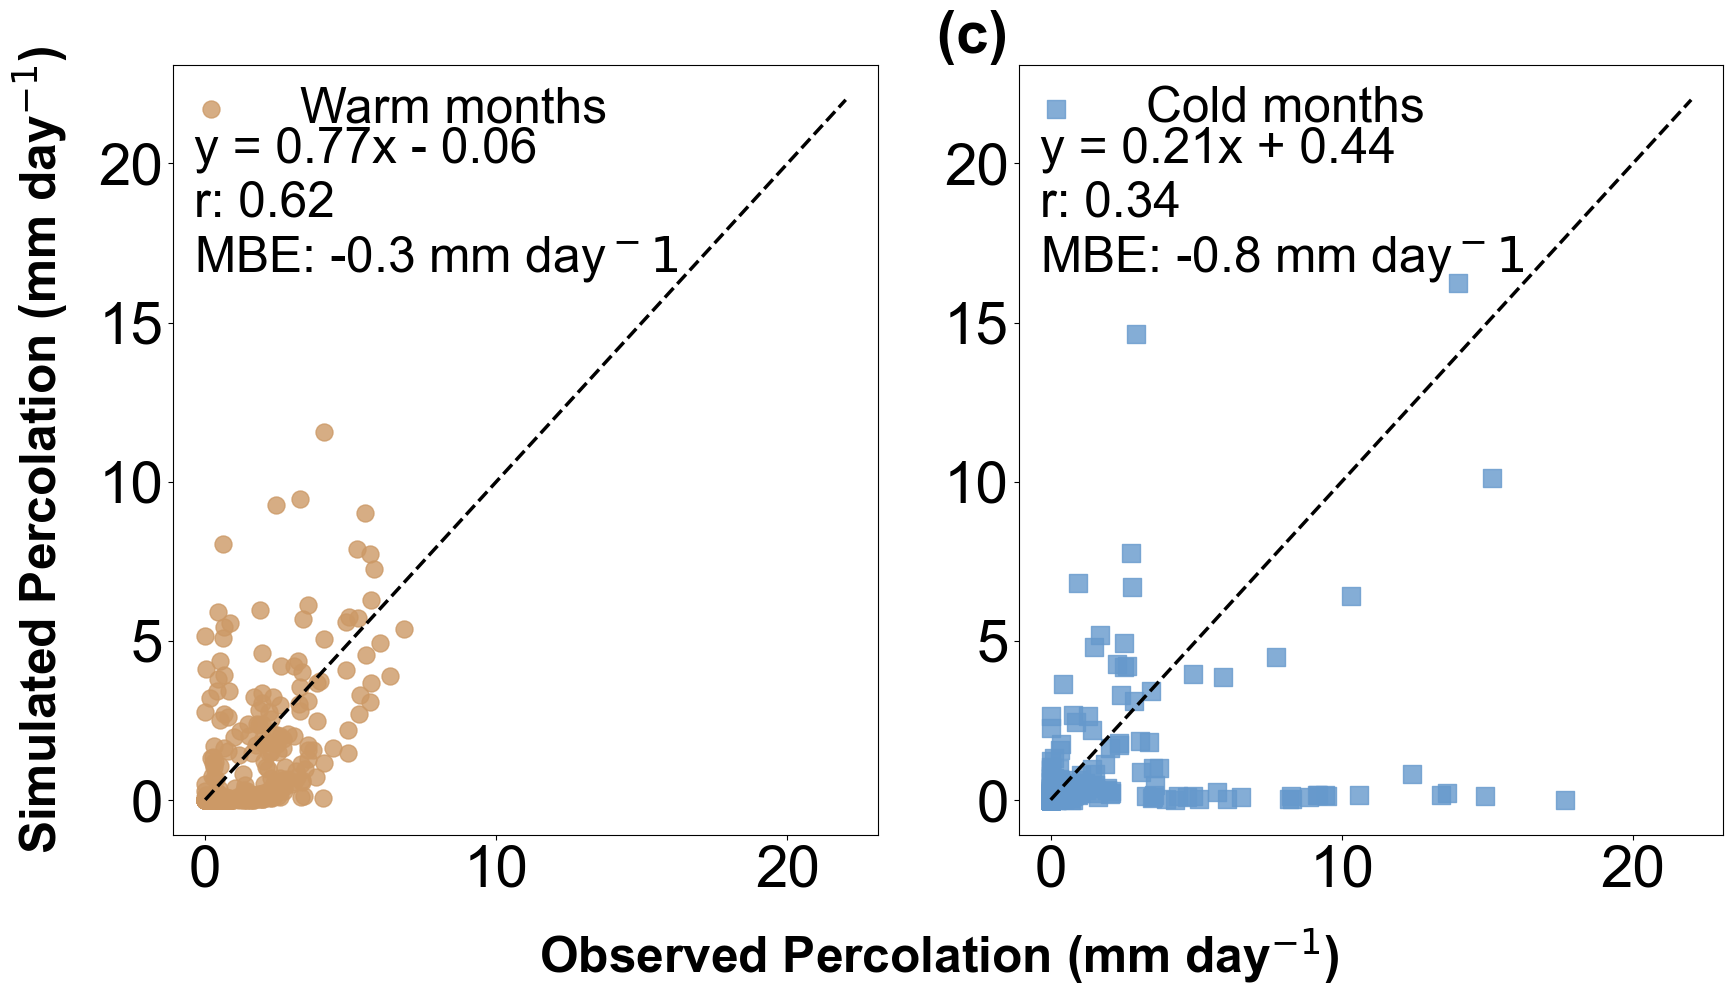

In [217]:
# Extract DP rates from the L1 and L2 lysimeters
lys1_dp = field_percolation.loc[field_percolation["Lysimeter Number"] == 1, "Reading"].copy()
lys2_dp = field_percolation.loc[field_percolation["Lysimeter Number"] == 2, "Reading"].copy()

# merge the two lysimeters
hourly_dp = pd.merge(lys1_dp, lys2_dp, left_index=True, right_index=True, suffixes=('_L1', '_L2'))

## resample to hourly to deal with the discontiguous time-index
hourly_dp = hourly_dp.resample('1h').agg(
    lambda x: np.sum(x) if not np.all(np.isnan(x)) else np.nan
)

# agg to daily
daily_dp = hourly_dp.resample('1d').agg(
    lambda x: np.sum(x) if not np.all(np.isnan(x)) else np.nan
)

## remove rows with both NaNs
daily_dp_nonan = daily_dp.dropna(how='all')

# load SVS output
print("Loading SVS deep percolation output ...")
hourly_dp_svs_ens = helpers.get_ensemble_output(
    output_files, ["ACC_DRAI"],
).pivot_table(
    index="date_utc", columns="member", values="DRAI"
)
print("Done.")

## convert to daily
daily_dp_svs_ens = hourly_dp_svs_ens.resample('1d').sum()

# find shared indices between the two datasets within PERIOD_1_D
shared_idx = daily_dp_nonan.index.intersection(daily_dp_svs_ens.index).intersection(PERIOD_1_D)

# calculate CRPS for the the period `shared_idx`
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=daily_dp_svs_ens.loc[shared_idx, :].values.astype(np.float32),
    yobs=daily_dp.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2019-09-01 to 2020-11-01): {crps_neigh:.4f}')

# find shared indices between the two datasets within PERIOD_2_D
shared_idx = daily_dp_nonan.index.intersection(daily_dp_svs_ens.index).intersection(PERIOD_2_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=daily_dp_svs_ens.loc[shared_idx, :].values.astype(np.float32),
    yobs=daily_dp.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2020-11-01 to 2021-11-01): {crps_neigh:.4f}')

# find shared indices between the two datasets within PERIOD_3_D
shared_idx = daily_dp_nonan.index.intersection(daily_dp_svs_ens.index).intersection(PERIOD_3_D)
print('Calculating neighborhood-based CRPS...\n')
crps_neigh = crps_neighboor(
    ens=daily_dp_svs_ens.loc[shared_idx, :].values.astype(np.float32),
    yobs=daily_dp.loc[shared_idx, :].values.astype(np.float32),
    chunk_size=10,
    njobs=4,
)
print(f'CRPS (2021-11-01 to 2022-11-01): {crps_neigh:.4f}')

# R2 and MBE for ensemble mean

dfsvs_stats = daily_dp_svs_ens.stack().reset_index().set_index("date_utc").rename(columns={0: "DRAI"})
dfsvs_stats = dd.from_pandas(dfsvs_stats, npartitions=10)
dfsvs_stats = dfsvs_stats.groupby("date_utc")["DRAI"].aggregate(
    ["mean", "min", "max", fivepct_fun, ninetyfivepct_fun]
).compute().astype(np.float32)

dfobs_stats = daily_dp_nonan.melt(ignore_index=False, value_name='obs', var_name='sample')
dfobs_stats = dd.from_pandas(dfobs_stats, npartitions=10)
dfobs_stats = dfobs_stats.groupby("Date Time (UTC)")["obs"].aggregate(
    ["mean", "min", "max"]
).compute().astype(np.float32)

## for the entire period
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Full period: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_1_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_1_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Period 1: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_2_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_2_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Period 2: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for PERIOD_3_D
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index).intersection(PERIOD_3_D)
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Period 3: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for WARM months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Warm months: R2 = {r2:.4f}, MBE = {mbe:.4f}")

## for COLD months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
r2, pval = pearsonr(dfobs_stats.loc[shared_idx, "mean"], dfsvs_stats.loc[shared_idx, "mean"])
mbe = dfsvs_stats.loc[shared_idx, "mean"].mean() - dfobs_stats.loc[shared_idx, "mean"].mean()
print(f"Cold months: R2 = {r2:.4f}, MBE = {mbe:.4f}")


# Plotting (daily time series) -------------------------------------------------
FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 38,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.7,
}


SAVE_P = paths['figures_dir'] / 'DailyDP_ts.pdf'
FIGSIZE = (20, 18)
LWIDTH = 2.5
DPI = 2000
plt.rcParams['font.sans-serif'] = 'Arial'

fig, ax = plt.subplots(3, 1, figsize=FIGSIZE, sharey=True, sharex=False)

# for the sake of plotting, merge the two dataframes
merged_stats_perc_d = pd.merge(
    dfobs_stats, dfsvs_stats, left_index=True, right_index=True, how='outer',
    suffixes=('_obs', '_svs'),
)

# period 1
## svs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[PERIOD_1_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_1_D, '5%'],
    merged_stats_perc_d.loc[PERIOD_1_D, '95%'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)

## svs ens mean
ax[0].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)

## obs ens range
ax[0].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'min_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_1_D), 'max_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)

## obs from L1
ax[0].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_1_D), 'Reading_L1'],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)

## obs from L2
ax[0].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_1_D), 'Reading_L2'],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 2
ax[1].fill_between(
    merged_stats_perc_d.loc[PERIOD_2_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_2_D, '5%'],
    merged_stats_perc_d.loc[PERIOD_2_D, '95%'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[1].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[1].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'min_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_2_D), 'max_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)
ax[1].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_2_D), 'Reading_L1'],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)
ax[1].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_2_D), 'Reading_L2'],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# period 3
ax[2].fill_between(
    merged_stats_perc_d.loc[PERIOD_3_D, 'mean_svs'].index,
    merged_stats_perc_d.loc[PERIOD_3_D, '5%'],
    merged_stats_perc_d.loc[PERIOD_3_D, '95%'],
    color=GOLD_BROWN, alpha=0.5,
    label='SVS ensemble'
)
ax[2].plot(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_svs'],
    color=GOLD_BROWN, label='SVS ensemble mean', linewidth=LWIDTH,
    linestyle='--',
)
ax[2].fill_between(
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'mean_obs'].index,
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'min_obs'],
    merged_stats_perc_d.loc[merged_stats_perc_d.index.isin(PERIOD_3_D), 'max_obs'],
    color=LIGHT_BLUE, alpha=0.5,
    label='Observed range'
)
ax[2].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_3_D), 'Reading_L1'],
    color='black', label='Observed L1', linewidth=LWIDTH,
    linestyle='-', alpha=0.75,
)
ax[2].plot(
    daily_dp.loc[daily_dp.index.isin(PERIOD_3_D), 'Reading_L2'],
    color=DARK_PURPLE, label='Observed L2', linewidth=LWIDTH,
    linestyle='-.', alpha=0.99,
)

# format
ax[0].set_title('(a)', fontdict=FONT)
ax[1].set_title('(b)', fontdict=FONT)
ax[2].set_title('(c)', fontdict=FONT)

for i in range(3):
    ax[i].set_ylabel('', fontdict=FONT)
    ax[i].set_xlabel('', fontdict=FONT)
    ax[i].tick_params(axis='both', which='major', labelsize=FONT['size'])
    ax[i].tick_params(axis='both', which='minor', labelsize=FONT['size'])
    ax[i].legend([], frameon=False)
    ax[i].set_ylim(0, 36)

ax[0].legend(
    loc='upper left', fontsize=SFONT['size'], frameon=False,
    ncol=2,
    bbox_to_anchor=(-0.01, 1.05),
)
# mm.d-1
ax[1].set_ylabel('Percolation (mm day$^{-1}$)', fontdict=FONT)

crps_ns = [0.6152, 0.1734, 0.8114]
MBE_s = [-0.23536813, -0.21075816, -1.4540533]
for i in range(3):
    ax[i].annotate(
        f'CRPS: {crps_ns[i]:.1f}' + 'mm day$^{-1}$' + '\n' + f'MBE: {MBE_s[i]:.1f}' + 'mm day$^{-1}$',
        xy=(0.78, 0.97), xycoords='axes fraction',
        fontsize=SFONT['size'], ha='left', va='top',
        # no background
    )

plt.tight_layout(pad=2.0)
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()

# Scatter plot -----------------------------------------------------------------
SAVE_P = paths['figures_dir'] / 'DailyDP_scatter.pdf'

FONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': 42,
}
SFONT = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'bold',
        'size': FONT['size'] * 0.85,
}

FIGSIZE = (20, 10)
MKSIZE = 150

fig, ax = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False, sharex=False)

# warm months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
ax[0].scatter(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=GOLD_BROWN, label='Warm months', s=MKSIZE, alpha=0.8, marker='o',
)

# cold months
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
ax[1].scatter(
    x= merged_stats_perc_d.loc[shared_idx, 'mean_obs'],
    y= merged_stats_perc_d.loc[shared_idx, 'mean_svs'],
    color=LIGHT_BLUE, label='Cold months', s=MKSIZE, alpha=0.8, marker='s',
)

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(WARM_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Warm months:')
print(f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f}, p-value: {p_value: .4f}')

# get slope and intercept
shared_idx = dfobs_stats.index.intersection(dfsvs_stats.index)
shared_idx = shared_idx[shared_idx.month.isin(COLD_MONTHS)]
mask = (
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_obs']) &
    ~np.isnan(merged_stats_perc_d.loc[shared_idx, 'mean_svs'])
)
slope, intercept, r_value, p_value, std_err = linregress(
    x=merged_stats_perc_d.loc[shared_idx, 'mean_obs'][mask],
    y=merged_stats_perc_d.loc[shared_idx, 'mean_svs'][mask]
)
print('Cold months:')
print(
    f'Slope: {slope: .4f}, Intercept: {intercept: .4f}, R: {r_value: .4f} '
    f' (r: {r_value: .4f}), p-value: {p_value: .4f}'
)

# format
for ax_ in ax:
    ax_.legend(
        loc='upper left', fontsize=SFONT['size'],
        frameon=False, framealpha=0.2,
        bbox_to_anchor=(-0.08, 1.03)
    )
    ax_.tick_params(axis='both', which='major', labelsize=FONT['size'])

ax[0].set_xlabel(60 * ' ' + 'Observed Percolation (mm day$^{-1}$)', fontdict=SFONT, labelpad=20)
ax[0].set_ylabel('Simulated Percolation (mm day$^{-1}$)', fontdict=SFONT, labelpad=20)
ax[0].set_title(55 * ' ' + '(c)', fontdict=FONT)

# 1:1 line,  for both
ax[0].plot([0.00, 22], [0.00, 22], color='black', linestyle='--', linewidth=LWIDTH)
ax[0].set_yticks([0.00, 5.0, 10.0, 15.0, 20.0])

# 1:1 line, 0.05 - 0.35 for both
ax[1].plot([0.00, 22], [0.00, 22], color='black', linestyle='--', linewidth=LWIDTH)
ax[1].set_yticks([0.00, 5.0, 10.0, 15.0, 20.0])

# annotate with slope and intercept
# warm
ax[0].annotate(
    f'y = 0.77x - 0.06\nr: 0.62\nMBE: -0.3 mm day$^{-1}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# cold
ax[1].annotate(
    f'y = 0.21x + 0.44\nr: 0.34\nMBE: -0.8 mm day$^{-1}$',
    xy=(0.03, 0.92), xycoords='axes fraction',
    fontsize=SFONT['size'], ha='left', va='top',
)

# save
plt.savefig(SAVE_P, bbox_inches='tight', dpi=DPI)
plt.show()